# MARKETING CAMPAIGN ANALYSIS

### 1. Data Understanding & Cleaning

In [18]:
import pandas as pd

df = pd.read_csv(r"C:\Users\mubi_\OneDrive\Desktop\Mubi\Courses\GUVI\Projects\Project2_Marketing Campaign Analysis\marketing_campaign_data.csv")
dic_df = pd.read_csv(r"C:\Users\mubi_\OneDrive\Desktop\Mubi\Courses\GUVI\Projects\Project2_Marketing Campaign Analysis\marketing_data_dictionary.csv")
df

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumStorePurchases,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Response,Complain,Country
0,342199,1985,Graduation,Together,59011.7,1,0,2012-11-17,3,0,...,3,4,0,0,0,0,0,0,0,Spain
1,8075450,1975,Master,Single,1730.0,1,1,2013-04-10,96,0,...,2,3,0,0,0,0,0,0,0,Spain
2,13664263,1978,Graduation,Married,98584.6,0,0,2014-01-11,99,920,...,6,3,0,0,0,0,0,0,0,Australia
3,16164787,1976,Graduation,Married,74031.5,1,0,2014-06-18,47,265,...,11,4,0,0,0,0,0,0,0,Spain
4,15815139,1981,Graduation,Divorced,52784.2,1,1,2014-05-20,0,30,...,3,6,0,0,0,0,0,0,0,Canada
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
55995,2485439,1985,Graduation,Married,32533.4,0,0,2013-04-05,99,8,...,6,8,0,0,0,0,0,0,0,Australia
55996,9202496,1992,Basic,Single,70496.3,0,1,2013-01-31,9,835,...,8,4,0,0,0,0,0,0,0,Germany
55997,14677746,1950,Graduation,Together,21072.0,1,0,2013-06-25,24,0,...,0,3,0,0,0,0,0,1,0,Saudi Arabia
55998,3843719,1976,Graduation,Together,64218.1,0,0,2014-05-12,81,8,...,1,8,0,0,0,0,0,0,0,Saudi Arabia


In [19]:
dic_df

,Field,Description
0,ID,Customer's unique identifier
1,Year_Birth,Customer's birth year
2,Education,Customer's education level
3,Marital_Status,Customer's marital status
4,Income,Customer's yearly household income
5,Kidhome,Number of children in customer's household
6,Teenhome,Number of teenagers in customer's household
7,Dt_Customer,Date of customer's enrollment with the company
8,Recency,Number of days since customer's last purchase
9,MntWines,Amount spent on wine in the last 2 years


#### Checking Duplicates

In [20]:
len(df) == df['ID'].nunique() # nunique()  --> returns the count of unique values

True

#### Checking Null Values

In [21]:
df.isna().sum()

ID                     0
Year_Birth             0
Education              0
Marital_Status         0
Income                 0
Kidhome                0
Teenhome               0
Dt_Customer            0
Recency                0
MntWines               0
MntFruits              0
MntMeatProducts        0
MntFishProducts        0
MntSweetProducts       0
MntGoldProds           0
NumDealsPurchases      0
NumWebPurchases        0
NumCatalogPurchases    0
NumStorePurchases      0
NumWebVisitsMonth      0
AcceptedCmp3           0
AcceptedCmp4           0
AcceptedCmp5           0
AcceptedCmp1           0
AcceptedCmp2           0
Response               0
Complain               0
Country                0
dtype: int64

In [22]:
dic_df.isna().sum()

Field          0
Description    0
dtype: int64

#### Checking each column datatype

In [23]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 56000 entries, 0 to 55999
Data columns (total 28 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ID                   56000 non-null  int64  
 1   Year_Birth           56000 non-null  int64  
 2   Education            56000 non-null  str    
 3   Marital_Status       56000 non-null  str    
 4   Income               56000 non-null  float64
 5   Kidhome              56000 non-null  int64  
 6   Teenhome             56000 non-null  int64  
 7   Dt_Customer          56000 non-null  str    
 8   Recency              56000 non-null  int64  
 9   MntWines             56000 non-null  int64  
 10  MntFruits            56000 non-null  int64  
 11  MntMeatProducts      56000 non-null  int64  
 12  MntFishProducts      56000 non-null  int64  
 13  MntSweetProducts     56000 non-null  int64  
 14  MntGoldProds         56000 non-null  int64  
 15  NumDealsPurchases    56000 non-null  int64  
 1

In [24]:
dic_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 28 entries, 0 to 27
Data columns (total 2 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   Field        28 non-null     str  
 1   Description  28 non-null     str  
dtypes: str(2)
memory usage: 2.1 KB


#### Preprocessing Data

In [25]:
# Deriving Columns

df['Age'] = 2026 - df['Year_Birth']

exp_cols = ["MntWines","MntFruits","MntMeatProducts","MntFishProducts","MntSweetProducts","MntGoldProds"]
df['Total_Spend'] = df[exp_cols].sum(axis=1) # axis = 1   ---> operations happen along the columns (row-wise)

purchase_cols = ['NumDealsPurchases','NumWebPurchases','NumCatalogPurchases','NumStorePurchases']
df['Total_Purchases'] = df[purchase_cols].sum(axis=1)

df['Children'] = df['Kidhome'] + df['Teenhome']

In [26]:
# Changing datatype of Dt_Customer to datetime format

df['Dt_Customer'] = pd.to_datetime(df['Dt_Customer'],errors='coerce',utc=True)

# Deriving Customer Tenure
reference_date = df['Dt_Customer'].max()
df['Customer_Tenure'] = (reference_date - df['Dt_Customer']).dt.days

# Changing the datatype to date format
df['Dt_Customer'] = df['Dt_Customer'].dt.date

In [27]:
#Checking for null values
df.isna().sum()

ID                     0
Year_Birth             0
Education              0
Marital_Status         0
Income                 0
Kidhome                0
Teenhome               0
Dt_Customer            0
Recency                0
MntWines               0
MntFruits              0
MntMeatProducts        0
MntFishProducts        0
MntSweetProducts       0
MntGoldProds           0
NumDealsPurchases      0
NumWebPurchases        0
NumCatalogPurchases    0
NumStorePurchases      0
NumWebVisitsMonth      0
AcceptedCmp3           0
AcceptedCmp4           0
AcceptedCmp5           0
AcceptedCmp1           0
AcceptedCmp2           0
Response               0
Complain               0
Country                0
Age                    0
Total_Spend            0
Total_Purchases        0
Children               0
Customer_Tenure        0
dtype: int64

### 2. EDA - Exploratory Data Analysis

### Customer Demographics

#### Univariate Analysis

AGE DISTRIBUTION

In [29]:
df['Age'].describe()

count    56000.000000
mean        54.333304
std         12.211066
min         30.000000
25%         45.000000
50%         53.000000
75%         63.000000
max         90.000000
Name: Age, dtype: float64

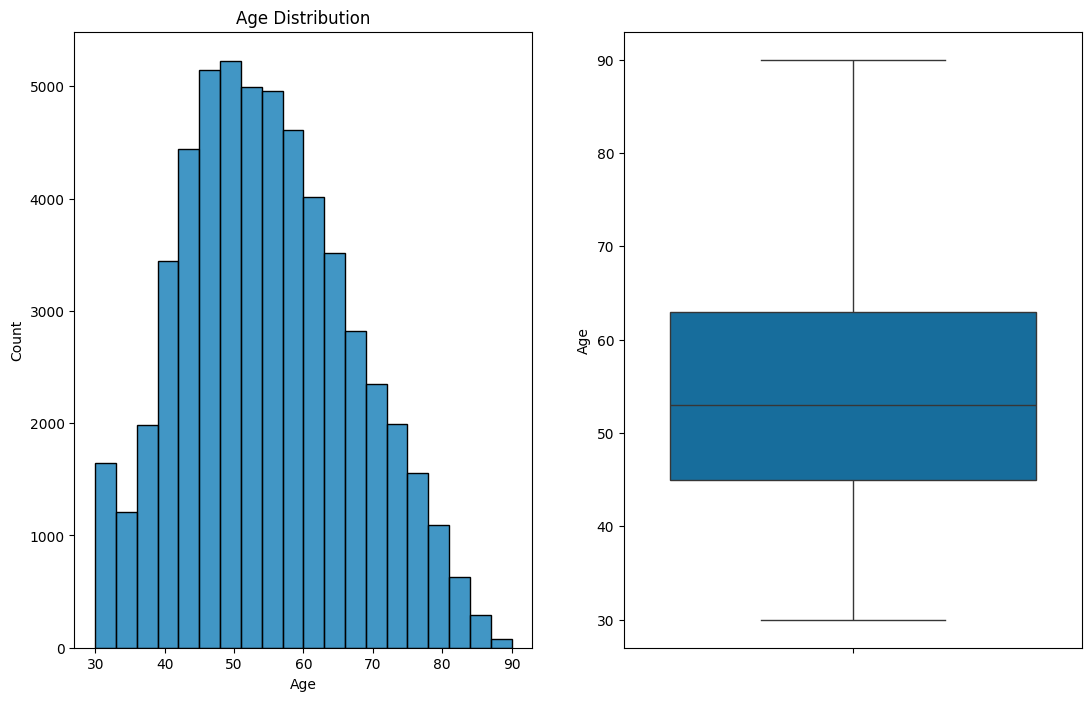

In [30]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

plt.figure(figsize=(13,8))
sns.set_palette("colorblind")
plt.subplot(1,2,1)
plt.title('Age Distribution')
sns.histplot(df['Age'], bins=20)

plt.subplot(1,2,2)
sns.boxplot(y = df['Age'])

plt.show()

Most Customers are between 40-65 years old which indicates that the company's primary customer base consists of middle-aged adults.


INCOME DISTRIBUTION

In [31]:
df['Income'].describe()

count     56000.000000
mean      57252.189521
std       34307.247999
min        1730.000000
25%       28252.025000
50%       58838.550000
75%       86930.650000
max      258027.500000
Name: Income, dtype: float64

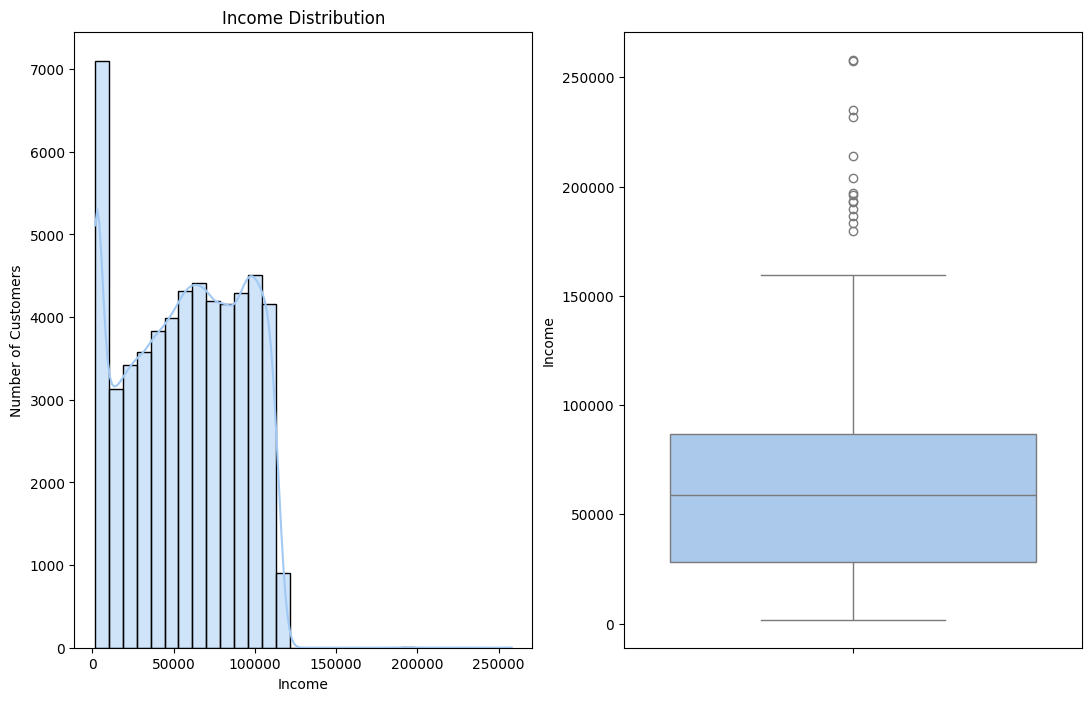

In [32]:
plt.figure(figsize=(13,8))
sns.set_palette("pastel")
plt.subplot(1,2,1)
sns.histplot(df['Income'],kde=True,bins=30)  # kde = True  --> Drawing a kernel density estimation line over a histogram
plt.title('Income Distribution')
plt.ylabel('Number of Customers')

plt.subplot(1,2,2)
sns.boxplot(y=df['Income'])

plt.show()

The boxplot indicates that there are outliers present in the income data (right side)

In [33]:
skewness_value_income = int(df['Income'].skew())
skewness_value_income

0

The skewness value indicates that it is perfectly symmetrical and the outliers are not severely distorting the distribution thus indicating that there seems to be a smaller number of high-income customers.

In [34]:
# Checking if Outliers are present using IQR (Inter Quartile Range)

Q1 = df['Income'].quantile(0.25) 
Q3 = df['Income'].quantile(0.75)

IQR = Q3-Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print(f"Lower Bound: {lower_bound}")
print(f"Min Income: {df['Income'].min()}\n")

print(f"Values below lower bound")
print(f"{df[df['Income'] < lower_bound][['Income']]}\n")

print(f"Upper Bound: {upper_bound}")
print(f"Max Income: {df['Income'].max()}\n")

count = (df['Income'] > upper_bound).sum()
print(f"Values above upper bound - {count}")
print(f"{df[df['Income'] > lower_bound][['Income']]}\n")

print(f"Outlier %: {(count/len(df)*100)}")



Lower Bound: -59765.912499999984
Min Income: 1730.0

Values below lower bound
Empty DataFrame
Columns: [Income]
Index: []

Upper Bound: 174948.58749999997
Max Income: 258027.5

Values above upper bound - 14
        Income
0      59011.7
1       1730.0
2      98584.6
3      74031.5
4      52784.2
...        ...
55995  32533.4
55996  70496.3
55997  21072.0
55998  64218.1
55999  89322.8

[56000 rows x 1 columns]

Outlier %: 0.025


Since the values are realistic and likely correspond to premium-income customers rather than data-entry errors, I have retained them for business analysis.

EDUCATION LEVEL

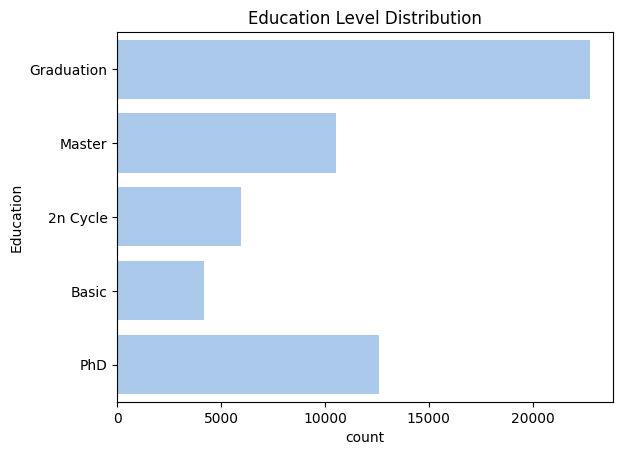

<Figure size 200x300 with 0 Axes>

In [35]:
sns.countplot(y='Education', data=df)
sns.set_palette('dark')
plt.title('Education Level Distribution')
plt.figure(figsize=(2,3))
plt.show()

Customers who are have done Graduation dominate the customer base

MARITAL STATUS

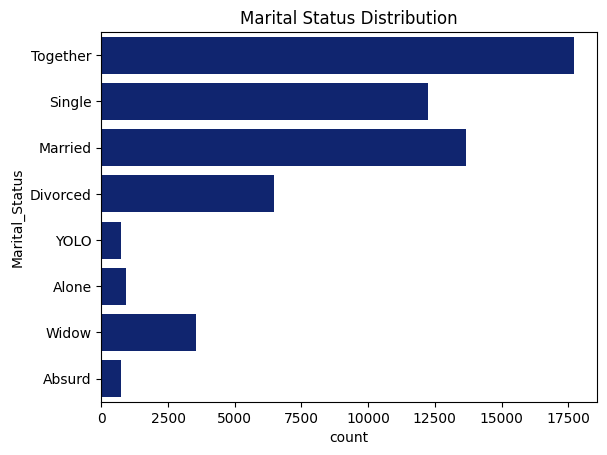

In [36]:
sns.countplot(y='Marital_Status', data=df)
sns.set_palette('muted')
plt.title('Marital Status Distribution')
plt.show()

From the above, Married and Together Customers form the largest segment

COUNTRY DISTRIBUTION

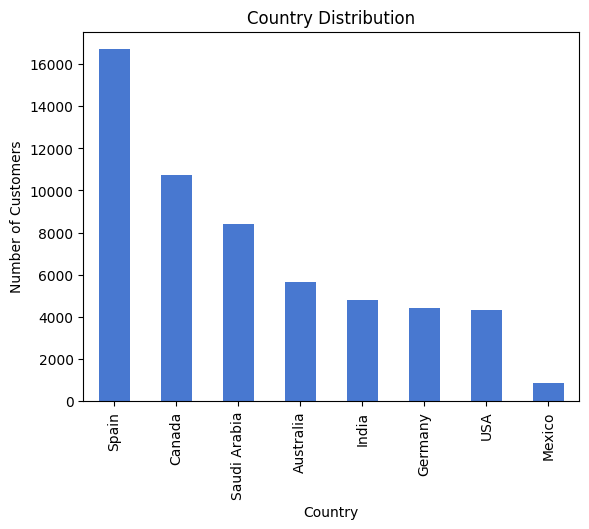

<Figure size 300x100 with 0 Axes>

In [37]:
df['Country'].value_counts().plot(kind='bar')
sns.set_palette('magma_r')
plt.title('Country Distribution')
plt.ylabel('Number of Customers')
plt.figure(figsize=(3,1))
plt.show()

Here, Spain contributes the majority of the customers.

#### Recency Analysis

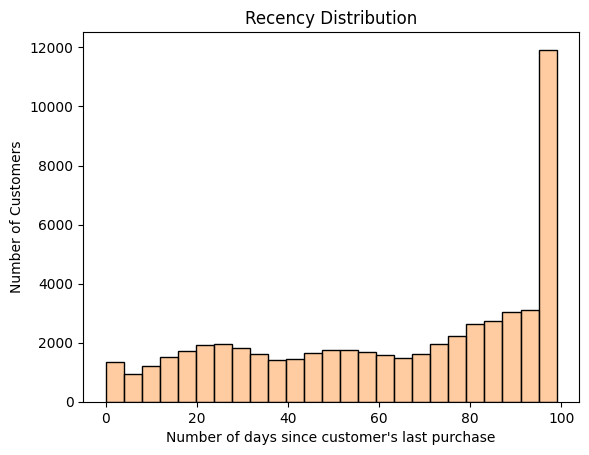

In [38]:
sns.histplot(df['Recency'],bins=25)
plt.title("Recency Distribution")
plt.xlabel("Number of days since customer's last purchase")
plt.ylabel('Number of Customers')
plt.show()

The recency values are spread from 0 to 99, but there is a very large spike at 99, which indicates many customers have very high recency meaning a large number of customers haven't purchased for a long time

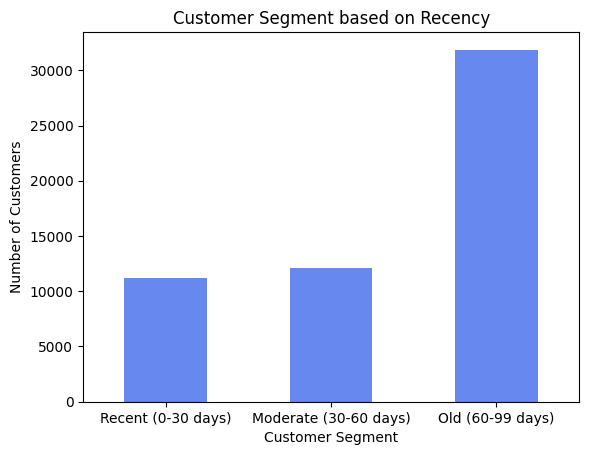

In [39]:
# Create recency bands
# Grouping recencies as 3 categories

recency_groups = pd.cut(df['Recency'], bins=[0,30,60,99],
                        labels=['Recent (0-30 days)','Moderate (30-60 days)','Old (60-99 days)'])
'''
pd.cut() -> function in pandas is used to segment and sort continuous numerical data into discrete intervals or bins.
         -> this process is known as data binning, is ideal for converting a continuous variable into a categorical variable
'''
sns.set_palette('coolwarm')
recency_groups.value_counts().sort_index().plot(kind='bar',xlabel='Customer Segment', ylabel='Number of Customers',title='Customer Segment based on Recency')
plt.xticks(rotation=0)
plt.show()

Campaign_response vs Recency

Recency
Recent (0-30 days)       15.866631
Moderate (30-60 days)    15.872754
Old (60-99 days)         13.771459
Name: Response, dtype: float64


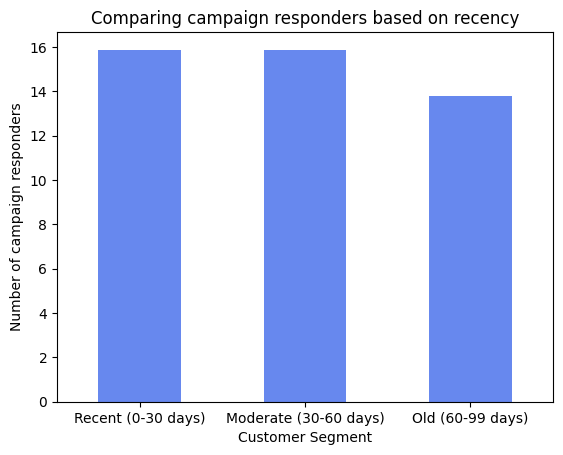

In [40]:
resp_vs_rec = df.groupby(recency_groups)['Response'].mean()*100
print(resp_vs_rec)

# Plotting bar graph
resp_vs_rec.plot(kind='bar',xlabel='Customer Segment',ylabel='Number of campaign responders',title='Comparing campaign responders based on recency')
plt.xticks(rotation=0)
plt.show()

The response rate of those customers who purchased recently seems to be slightly higher than the customers who purchased a long time ago

Average Spending vs Recency

Recency
Recent (0-30 days)       699.744882
Moderate (30-60 days)    670.340366
Old (60-99 days)         601.738286
Name: Total_Spend, dtype: float64


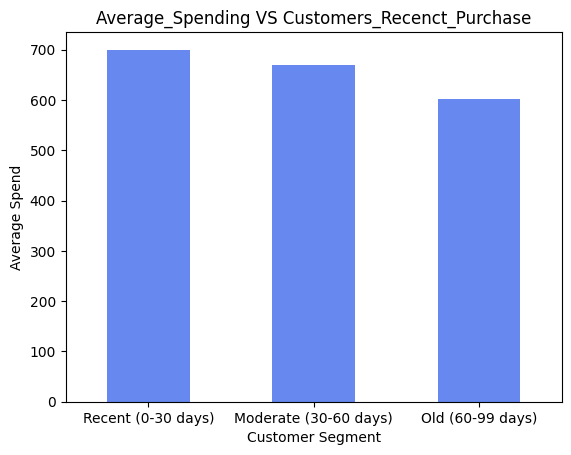

In [41]:
avg_spend_vs_rec = df.groupby(recency_groups)['Total_Spend'].mean()
print(avg_spend_vs_rec)

avg_spend_vs_rec.plot(kind='bar',xlabel='Customer Segment',ylabel='Average Spend',title='Average_Spending VS Customers_Recenct_Purchase')
plt.xticks(rotation=0)
plt.show()

SPENDING ANALYSIS

MntMeatProducts     15024465
MntWines            13830963
MntFishProducts      2861473
MntGoldProds         1981595
MntSweetProducts     1255691
MntFruits             904549
dtype: int64

MntMeatProducts     268.294018
MntWines            246.981482
MntFishProducts      51.097732
MntGoldProds         35.385625
MntSweetProducts     22.423054
MntFruits            16.152661
dtype: float64


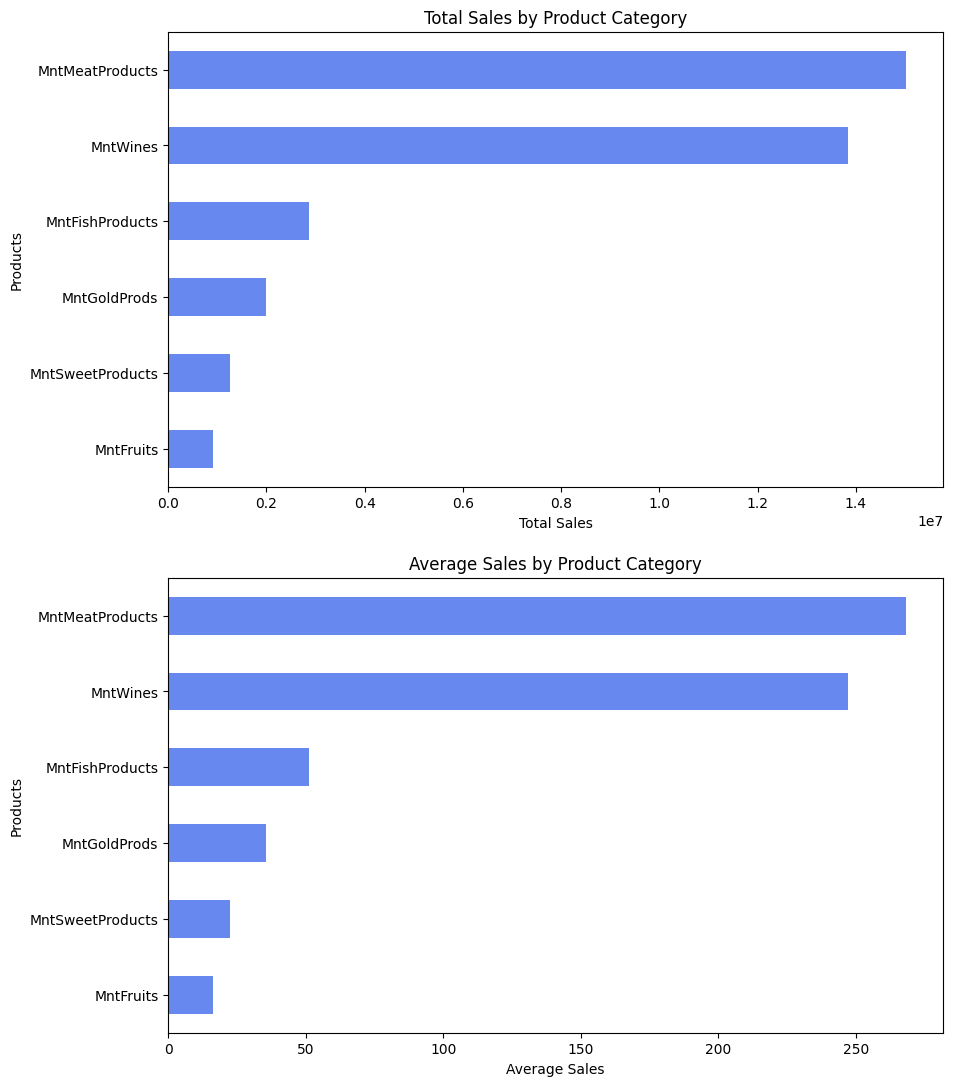

In [42]:
# Product-wise Spending

exp_cols = ["MntWines","MntFruits","MntMeatProducts","MntFishProducts","MntSweetProducts","MntGoldProds"]
print(df[exp_cols].sum().sort_values(ascending=False))

plt.subplot(2,1,1)
df[exp_cols].sum().sort_values().plot(kind='barh', figsize=(10,13),ylabel='Products',xlabel='Total Sales')
plt.title('Total Sales by Product Category')

#Average Product Spend

print(f"\n{df[exp_cols].mean().sort_values(ascending=False)}")
plt.subplot(2,1,2)
df[exp_cols].mean().sort_values().plot(kind='barh', figsize=(10,13),ylabel='Products',xlabel='Average Sales')
plt.title('Average Sales by Product Category')
plt.show()

Spending Patterns accross products

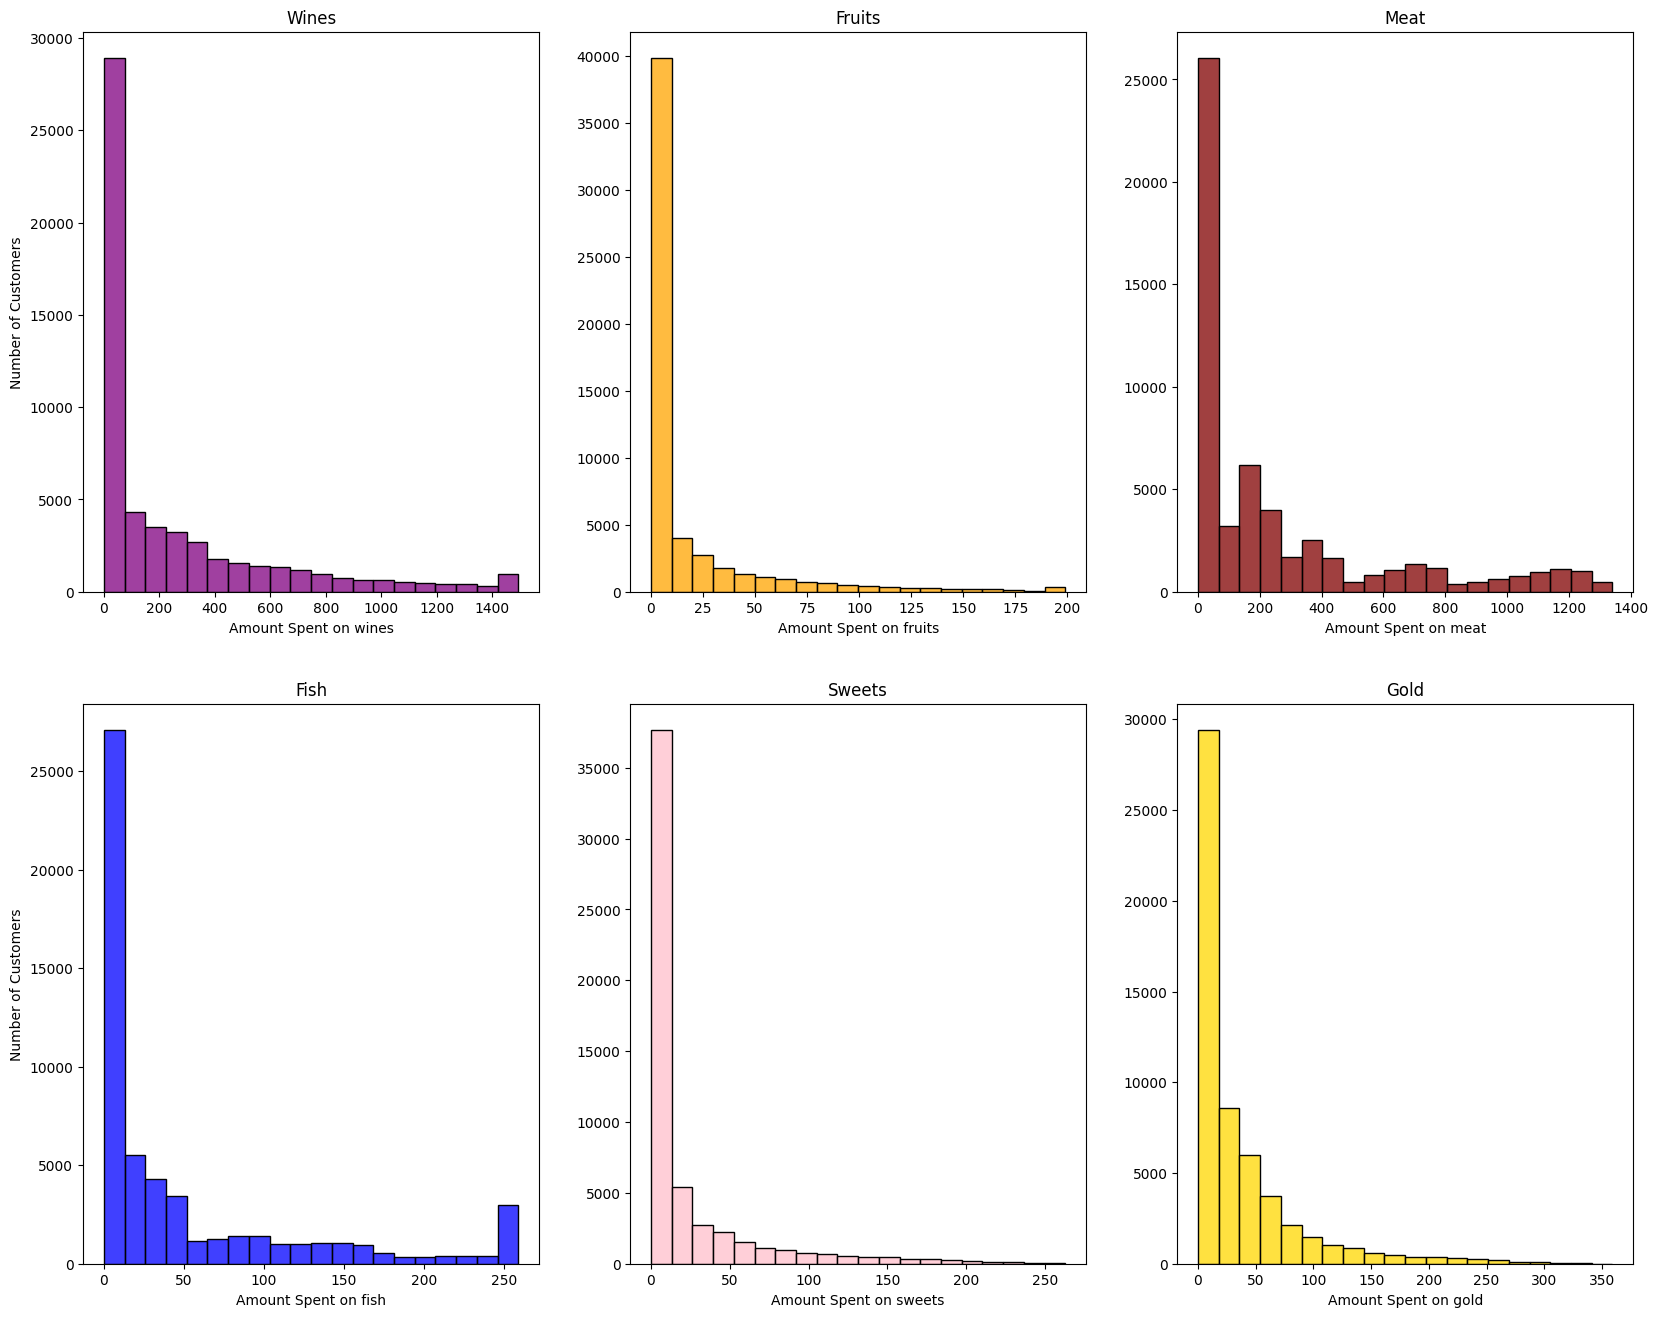

In [43]:
# Product Spend Distribution

plt.figure(figsize=(20,16))
plt.subplot(2,3,1)

sns.histplot(df['MntWines'], bins=20,color='purple')
plt.title('Wines')
plt.ylabel('Number of Customers')
plt.xlabel('Amount Spent on wines')

plt.subplot(2,3,2)
sns.histplot(df['MntFruits'],bins=20,color='orange')
plt.xlabel('Amount Spent on fruits')
plt.ylabel('')
plt.title('Fruits')

plt.subplot(2,3,3)
sns.histplot(df['MntMeatProducts'],bins=20,color='maroon')
plt.xlabel('Amount Spent on meat')
plt.ylabel('')
plt.title('Meat')

plt.subplot(2,3,4)
sns.histplot(df['MntFishProducts'],bins=20,color='blue')
plt.xlabel('Amount Spent on fish')
plt.ylabel('Number of Customers')
plt.title('Fish')

plt.subplot(2,3,5)
sns.histplot(df['MntSweetProducts'],bins=20,color='pink')
plt.xlabel('Amount Spent on sweets')
plt.ylabel('')
plt.title('Sweets')

plt.subplot(2,3,6)
sns.histplot(df['MntGoldProds'],bins=20,color='gold')
plt.xlabel('Amount Spent on gold')
plt.ylabel('')
plt.title('Gold')

plt.show()

SPENDING DISTRIBUTION

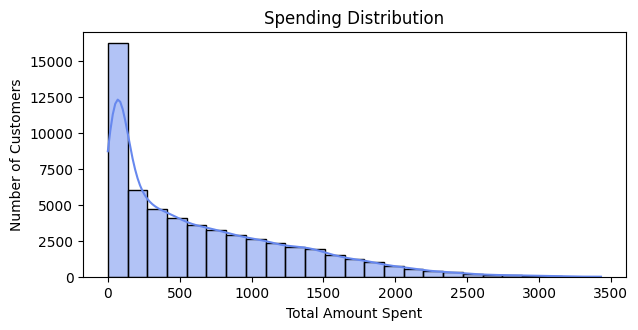

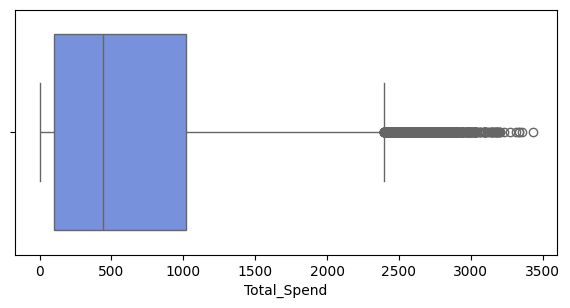

In [44]:
plt.figure(figsize=(7,7))
plt.subplot(2,1,1)
plt.title('Spending Distribution')
plt.ylabel('Number of Customers')
plt.xlabel('Total Amount Spent')
sns.histplot(df['Total_Spend'],bins=25, kde=True)

plt.figure(figsize=(7,7))
plt.subplot(2,1,2)
sns.boxplot(x = df['Total_Spend'])
plt.show()

In [ ]:
# Identifying outliers using IQR

Q1 = df['Total_Spend'].quantile(0.25) 
Q3 = df['Total_Spend'].quantile(0.75)

IQR = Q3-Q1

lb = Q1 - 1.5*IQR
ub = Q3 + 1.5*IQR

print(f"Lower Bound: {lb}")
print(f"Minimum: {df['Total_Spend'].min()}")
print(f"Values below lower bound: {(df['Total_Spend'] < lb).sum()}")
print(f"{df[df['Total_Spend'] < lb][['Total_Spend']]}\n")

print(f"Upper Bound: {ub}")
print(f"Maximum: {df['Total_Spend'].max()}")
print(f"Values above upper bound: {(df['Total_Spend'] > ub).sum()}")
print(f"{df[df['Total_Spend'] > ub][['Total_Spend']]}\n")

# Outlier percentage

outliers = (df['Total_Spend'] > ub).sum()
outlier_percentage = outliers/len(df)*100
print(f"Outliers %: {outlier_percentage}")

Lower Bound: -1272.5
Minimum: 0
Values below lower bound: 0
Empty DataFrame
Columns: [Total_Spend]
Index: []

Upper Bound: 2395.5
Maximum: 3431
Values above upper bound: 705
       Total_Spend
53            2517
94            2913
145           2774
177           2454
206           2540
...            ...
55645         2404
55771         2558
55924         2613
55928         2721
55966         2509

[705 rows x 1 columns]

Outliers %: 1.2589285714285714


In [47]:
# Investigating the outliers

outliers = df[(df['Total_Spend'] < lb) | (df['Total_Spend'] > ub)]
outliers[['Income','Age','Total_Spend','Response']].describe()

,Income,Age,Total_Spend,Response
count,705.000000,705.000000,705.000000,705.000000
mean,93288.888652,59.411348,2662.957447,0.310638
std,19681.076750,12.776082,216.670783,0.463083
min,6729.600000,30.000000,2396.000000,0.000000
25%,83031.700000,49.000000,2485.000000,0.000000
50%,98735.700000,60.000000,2611.000000,0.000000
75%,109052.800000,69.000000,2815.000000,1.000000
max,117964.000000,89.000000,3431.000000,1.000000


In [48]:
outliers.sort_values('Total_Spend',ascending=False).head(10)

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,AcceptedCmp1,AcceptedCmp2,Response,Complain,Country,Age,Total_Spend,Total_Purchases,Children,Customer_Tenure
16653,5753845,1964,Master,Divorced,106284.4,0,0,2013-08-15,38,1493,...,0,0,0,0,Australia,62,3431,17,0,318
50061,6943845,1973,PhD,Together,110978.8,0,0,2012-11-09,3,1493,...,0,0,0,0,Canada,53,3355,13,0,597
22273,13759135,1957,PhD,Single,114183.7,0,1,2013-12-08,76,1493,...,0,0,1,0,Australia,69,3338,20,1,203
33887,16522661,1964,Graduation,Single,97871.5,0,0,2013-02-04,21,1477,...,1,0,0,0,Canada,62,3338,24,0,510
5070,13943936,1953,Graduation,Together,114483.0,0,0,2013-01-25,86,1493,...,0,0,0,0,Australia,73,3314,16,0,520
39179,10694541,1962,2n Cycle,Together,100601.6,0,0,2013-01-28,0,1424,...,0,0,0,0,Canada,64,3270,12,0,517
8394,14059885,1984,Graduation,Alone,85036.2,0,0,2014-06-29,68,1493,...,0,0,1,0,Spain,42,3234,26,0,0
17592,2837885,1966,PhD,Married,116832.6,0,0,2013-07-31,73,1493,...,0,0,1,0,Saudi Arabia,60,3203,15,0,333
55371,2295475,1971,PhD,Divorced,111109.4,0,1,2013-01-31,90,1378,...,1,0,1,0,Canada,55,3201,13,1,514
27202,16471314,1960,Master,Married,114724.5,0,1,2012-11-19,33,1493,...,0,0,0,0,Saudi Arabia,66,3198,11,1,587


IQR analysis identified a set of high-spending customers. Investigation showed that these customers generally have high incomes, multiple purchases, and in several cases higher campaign responsiveness. Since the values represent genuine customer behavior rather than data-entry errors, they were retained for further analysis and treated as a high-value customer segment.

### BIVARIATE ANALYSIS

Spending vs Income

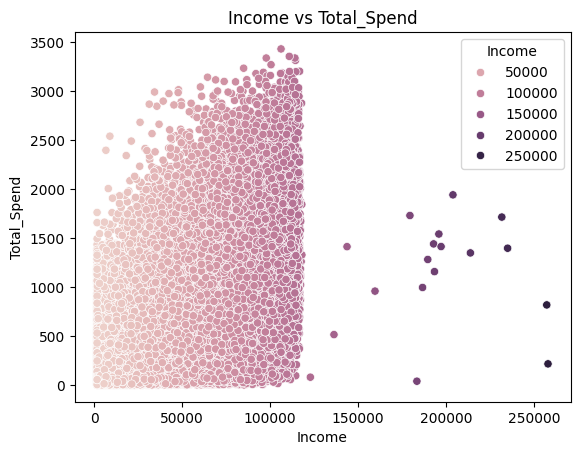

In [49]:
sns.scatterplot(data=df, x='Income',y='Total_Spend',hue='Income')
plt.title('Income vs Total_Spend')
plt.show()

In [50]:
df[['Income','Total_Spend']].corr()

,Income,Total_Spend
Income,1.000000,0.572882
Total_Spend,0.572882,1.000000


Income and Total Spend exhibit a moderate positive correlation (r = 0.573). Higher-income customers generally spend more, but spending behaviour varies considerably among customers with similar incomes, suggesting that additional factors such as age, family consumption, purchasing channels, and campaign engagement also influence customer spending.

Spending vs Age

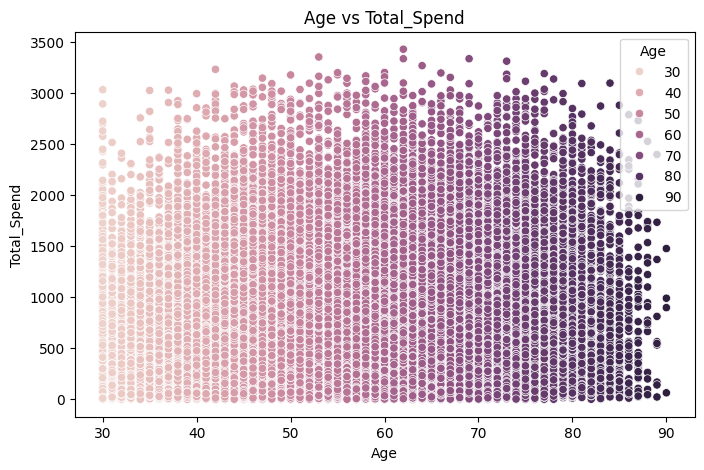

In [51]:
plt.figure(figsize=(8,5))
plt.title('Age vs Total_Spend')
sns.scatterplot(data=df, x='Age', y='Total_Spend',hue='Age')

plt.show()

In [52]:
# Correlation between 2 variables -> strength and direction of relationship between 2 variables
# Total_Spend -> Currency, Age -> Years

df[['Total_Spend','Age']].corr()

,Total_Spend,Age
Total_Spend,1.000000,0.186841
Age,0.186841,1.000000


Correlation value (r=0.19) means as age increases, total spend tends to increase slightly, but the relationship is weak. Age alone is not a strong predictor of customer spending.

Spending vs Marital Status

Marital_Status
Divorced    753.909429
Widow       745.052260
Alone       701.286498
Single      688.187531
YOLO        665.593151
Absurd      655.349250
Together    644.772355
Married     504.908666
Name: Total_Spend, dtype: float64


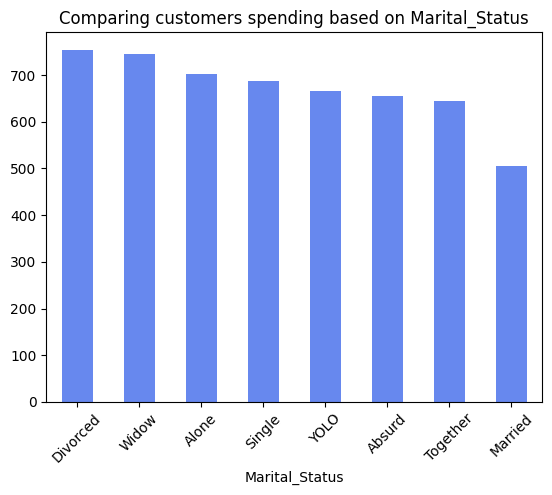

In [53]:
print(df.groupby('Marital_Status')['Total_Spend'].mean().sort_values(ascending=False))

df.groupby('Marital_Status')['Total_Spend'].mean().sort_values(ascending=False).plot(kind='bar')
plt.xticks(rotation=45)
plt.title('Comparing customers spending based on Marital_Status')
plt.show()

Spending vs Children

Children
0    942.700304
3    586.902394
1    539.757061
2    400.706766
4    381.333333
Name: Total_Spend, dtype: float64


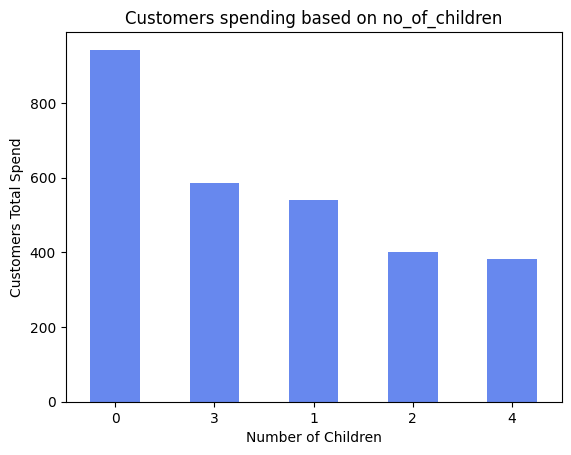

In [54]:
print(df.groupby('Children')['Total_Spend'].mean().sort_values(ascending=False))

df.groupby('Children')['Total_Spend'].mean().sort_values(ascending=False).plot(
    kind='bar', title='Customers spending based on no_of_children',xlabel='Number of Children',ylabel='Customers Total Spend')
plt.xticks(rotation=0)
plt.show()

Spending vs Campaign Response

<Axes: title={'center': 'Customers spending based on campaign response'}, xlabel='Campaign Response (0-no, 1-yes)', ylabel='Amount spent by customers'>

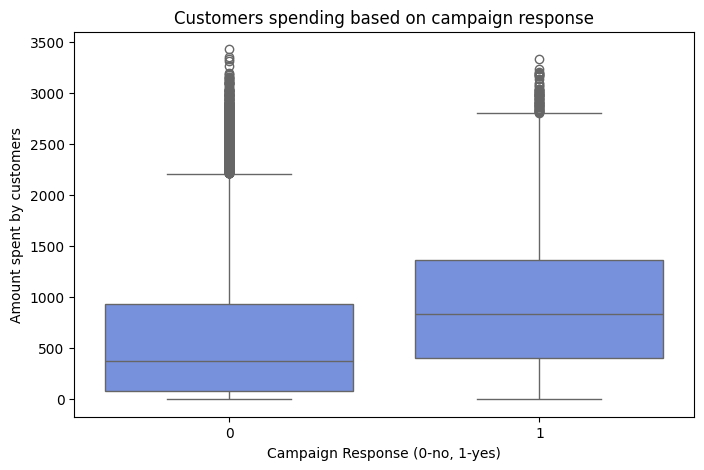

In [55]:
plt.figure(figsize=(8,5))
plt.title('Customers spending based on campaign response')
plt.ylabel('Amount spent by customers')
plt.xlabel('Campaign Response (0-no, 1-yes)')
sns.boxplot(data=df, x='Response', y='Total_Spend') 

The boxplot shows that customers who responded to the marketing campaign generally have higher total spending than those who did not respond. The higher median and interquartile range for responders indicate that campaigns are more likely to attract higher-value customers. However, the presence of high-spending non-responders suggests that there is still scope to improve campaign effectiveness by better targeting valuable customers.

In [56]:
df.groupby('Response')['Total_Spend'].agg(['mean','median','count'])

,mean,median,count
Response,,,
0,588.571593,375.0,47735
1,939.294737,833.0,8265


Customers who responded to the campaign have both a higher average and median spending than non-responders, reinforcing that campaign responders are generally more valuable customers.

## Channel Usage Analysis

DISTRIBUTION OF PURCHASES

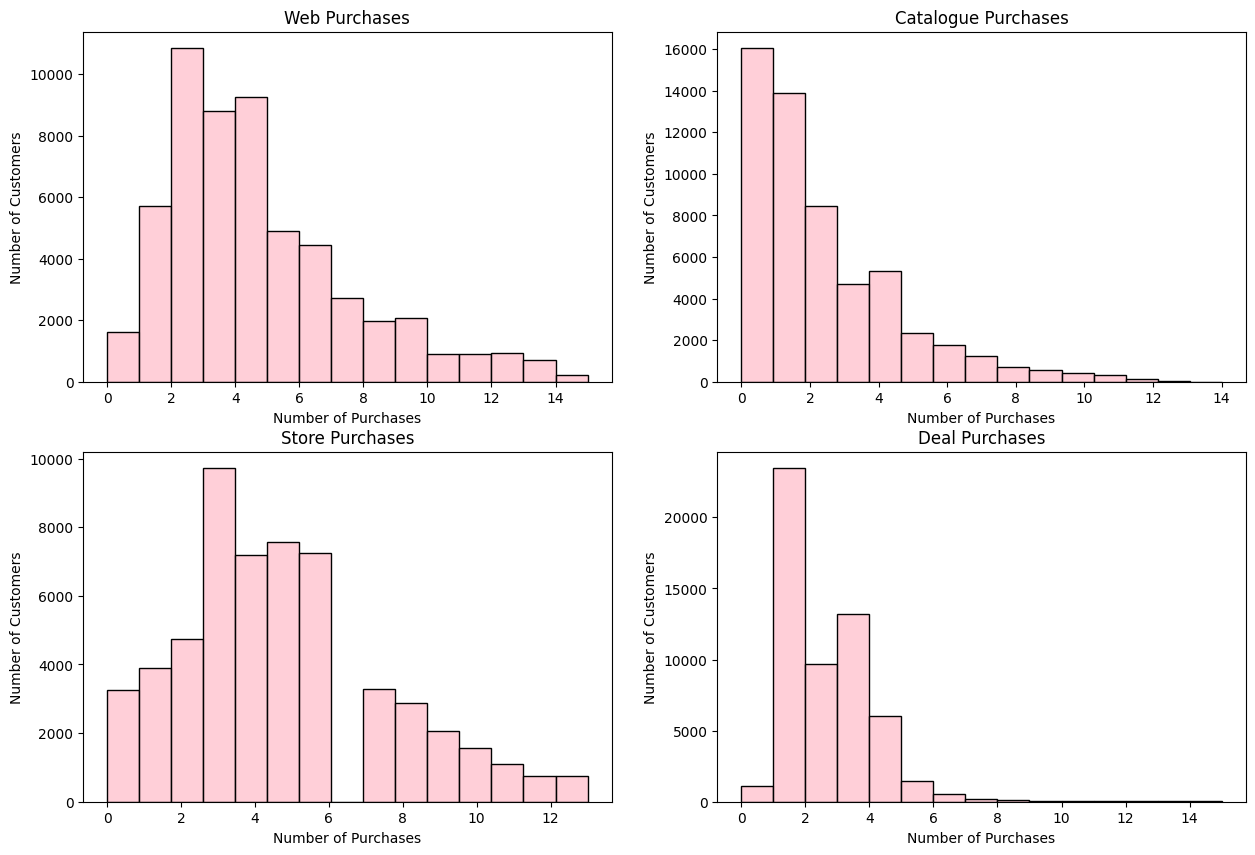

In [57]:
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt

channels = ['NumWebPurchases','NumCatalogPurchases','NumStorePurchases','NumDealsPurchases']
titles = ['Web Purchases','Catalogue Purchases','Store Purchases','Deal Purchases']

plt.figure(figsize=(15,10))

for i, (col, title) in enumerate(zip(channels, titles), start=1):
    plt.subplot(2,2,i)
    sns.histplot(df[col],bins=15,color='pink')
    plt.title(title)
    plt.xlabel('Number of Purchases')
    plt.ylabel('Number of Customers')
        
plt.show()

AVERAGE PURCHASES

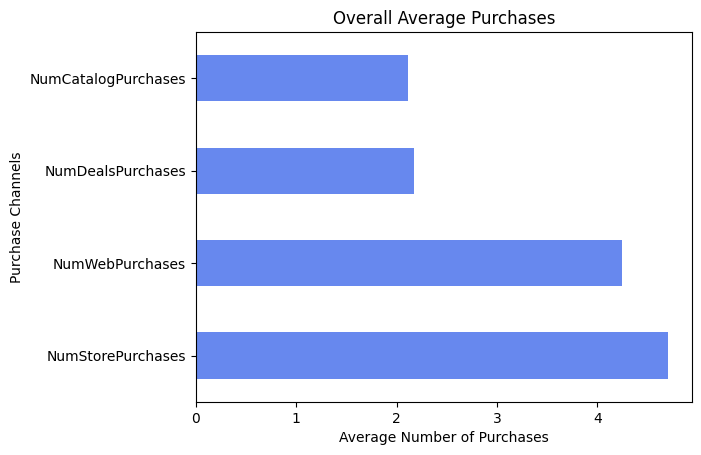

NumStorePurchases      4.706411
NumWebPurchases        4.248893
NumDealsPurchases      2.171964
NumCatalogPurchases    2.110750
dtype: float64


In [58]:
avg_purchases = df[channels].mean().sort_values(ascending=False)

avg_purchases.plot(kind='barh')
plt.xlabel("Average Number of Purchases")
plt.title('Overall Average Purchases')
plt.ylabel("Purchase Channels")
plt.show()

print(avg_purchases)

On an average, each customer makes 4.7 store purchases, compared to only 2.1 catalogue purchases.

BOXPLOTS

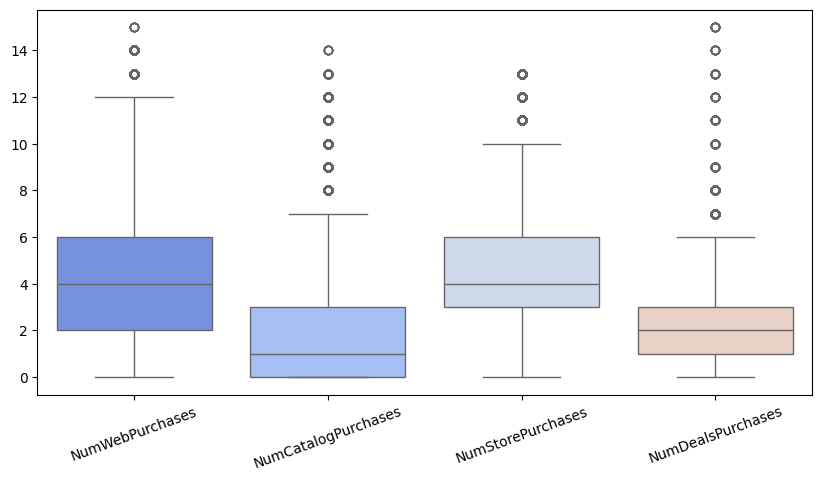

NumWebPurchases        1.103284
NumCatalogPurchases    1.573386
NumStorePurchases      0.631243
NumDealsPurchases      1.594838
dtype: float64


In [59]:
plt.figure(figsize=(10,5))
sns.boxplot(data=df[channels])
plt.xticks(rotation=20)
plt.show()

print(df[channels].skew())

The purchase channels exhibit varying degrees of positive skewness. Store purchases are moderately positively skewed (0.63), suggesting that in-store shopping is relatively common across customers. In contrast, web, catalog, and deal purchases are highly positively skewed (skewness > 1), indicating that most customers make only a few purchases through these channels, while a small subset of customers uses these channels extensively. This suggests that digital, catalog, and promotional channels are dominated by specific customer segments rather than the overall customer base.

### Web Visits

#### Deriving Web_Visitor_Type column

In [60]:
def web_engagement(visits):
    if visits <= 2:
        return 'Occasional'
    elif visits <= 5:
        return 'Moderate'
    else:
        return 'Frequent'
    
df['Web_Visitor_Type'] = df['NumWebVisitsMonth'].apply(web_engagement)

##### Web_Visitor_Type comparison with Spending

,Web_Visitor_Type,No.of Visits,Average Spending
0,Frequent,29970,510.078912
1,Moderate,15903,701.879960
2,Occasional,10127,929.166979


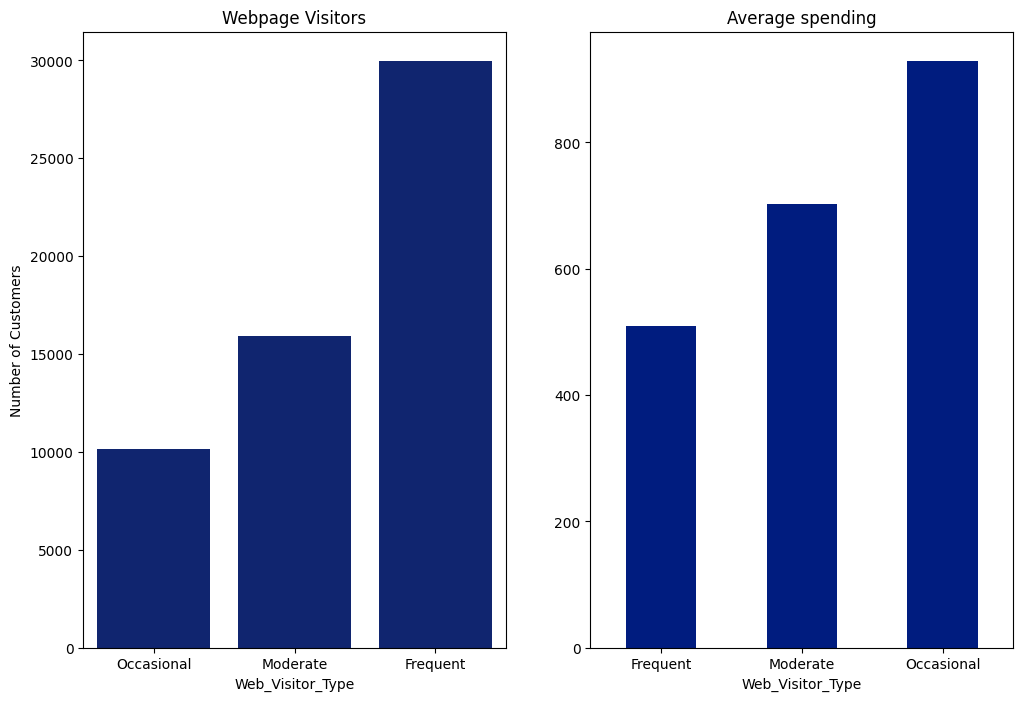

In [61]:
plt.figure(figsize=(12,8))
sns.set_palette('dark')
plt.subplot(1,2,1)
plt.title('Webpage Visitors')
sns.countplot(data=df, x='Web_Visitor_Type', order=['Occasional','Moderate','Frequent'])
plt.ylabel('Number of Customers')

plt.subplot(1,2,2)
df.groupby('Web_Visitor_Type')['Total_Spend'].mean().plot(kind='bar',title='Average spending')
plt.xticks(rotation=0)
plt.plot()

webpage_df = pd.DataFrame(df['Web_Visitor_Type'].value_counts().index)
webpage_df['No.of Visits'] = df['Web_Visitor_Type'].value_counts(ascending=False).values
webpage_df['Average Spending'] = df.groupby('Web_Visitor_Type')['Total_Spend'].mean().values
webpage_df

Correlation relationship between Webpage visitors and Spending

In [62]:
df[['NumWebVisitsMonth','Total_Spend']].corr()

,NumWebVisitsMonth,Total_Spend
NumWebVisitsMonth,1.000000,-0.263959
Total_Spend,-0.263959,1.000000


There is a weak negative correlation between the number of monthly website visits and average customer spending. This indicates that customers who visit the website more frequently tend to spend slightly less, although the relationship is not strong.

##### Web_Visitor_Type comparison with Campaign_Response

,Web_Visitor_Type,No.of Visits,Campaign_Responders
0,Frequent,29970,12.072072
1,Moderate,15903,16.009558
2,Occasional,10127,20.746519


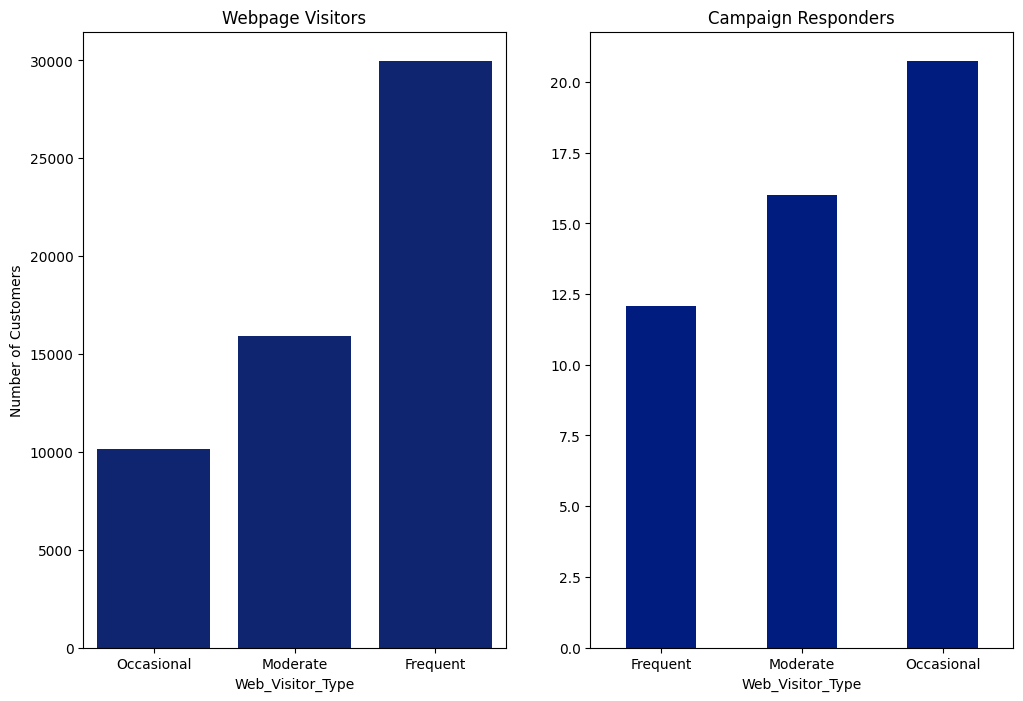

In [63]:
plt.figure(figsize=(12,8))
plt.subplot(1,2,1)
plt.title('Webpage Visitors')
sns.countplot(data=df, x='Web_Visitor_Type', order=['Occasional','Moderate','Frequent'])
plt.ylabel('Number of Customers')


plt.subplot(1,2,2)
(df.groupby('Web_Visitor_Type')['Response'].mean()*100).plot(kind='bar',title='Campaign Responders')
plt.xticks(rotation=0)
plt.plot()

webpage_df = pd.DataFrame(df['Web_Visitor_Type'].value_counts().index)
webpage_df['No.of Visits'] = df['Web_Visitor_Type'].value_counts(ascending=False).values
webpage_df['Campaign_Responders'] = (df.groupby('Web_Visitor_Type')['Response'].mean()*100).values
webpage_df

Correlation relationship between Webpage visitors and Campaign_Responders

In [64]:
df[['NumWebVisitsMonth','Response']].corr()

,NumWebVisitsMonth,Response
NumWebVisitsMonth,1.000000,-0.096774
Response,-0.096774,1.000000


There is a very weak negative correlation between the number of monthly website visits and campaign responders. This indicates that customers who visit the website less frequently (occasionally) tend to respond to the campaign more, although the relationship is not strong.

Comparison of web_purchases with web_visits

In [65]:
df.groupby("Web_Visitor_Type")[["NumWebVisitsMonth", "NumWebPurchases"]].mean()

,NumWebVisitsMonth,NumWebPurchases
Web_Visitor_Type,,
Frequent,7.202903,3.914381
Moderate,4.058731,4.486323
Occasional,0.899477,4.866002


### Campaign Analysis

#### Campaign Acceptance

              0  Average_Performance
0  AcceptedCmp1            13.444643
1  AcceptedCmp2             1.441071
2  AcceptedCmp3             6.239286
3  AcceptedCmp4             5.682143
4  AcceptedCmp5             4.566071
5      Response            14.758929


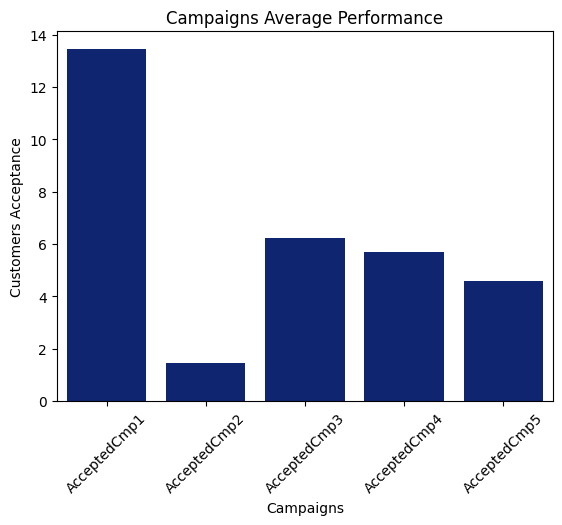

In [66]:
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt

campaign_cols = ['AcceptedCmp1','AcceptedCmp2','AcceptedCmp3','AcceptedCmp4','AcceptedCmp5','Response']

campaign = pd.DataFrame(df[campaign_cols].mean().index)
campaign['Average_Performance'] = (df[campaign_cols].mean()*100).values
print(campaign)

plt.title('Campaigns Average Performance')
sns.set_palette('pastel')
sns.barplot((df[campaign_cols].mean()*100)[:5])
plt.xlabel('Campaigns')
plt.ylabel('Customers Acceptance')
plt.xticks(rotation=45)

plt.show()

In [78]:
df.columns

Index(['ID', 'Year_Birth', 'Education', 'Marital_Status', 'Income', 'Kidhome',
       'Teenhome', 'Dt_Customer', 'Recency', 'MntWines', 'MntFruits',
       'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts',
       'MntGoldProds', 'NumDealsPurchases', 'NumWebPurchases',
       'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth',
       'AcceptedCmp3', 'AcceptedCmp4', 'AcceptedCmp5', 'AcceptedCmp1',
       'AcceptedCmp2', 'Response', 'Complain', 'Country', 'Age', 'Total_Spend',
       'Total_Purchases', 'Children', 'Customer_Tenure', 'Web_Visitor_Type'],
      dtype='str')

#### Response Rate by Demographics

Age
Young Adults (18-30)    10.572260
Adults (31-45)          12.426966
Middle-Aged (46-60)     14.111548
Seniors (60+)           17.796810
Name: Response, dtype: float64


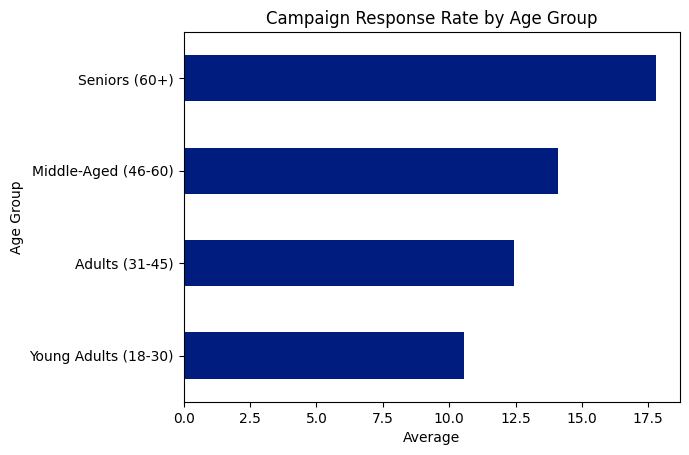

In [ ]:
# Response vs AGE
age_group = pd.cut(df['Age'],bins=[0, 30, 45, 60, df['Age'].max()],
                    labels=['Young Adults (18-30)','Adults (31-45)', 'Middle-Aged (46-60)','Seniors (60+)'])

grp_age = df.groupby(age_group)['Response'].mean()*100
print(grp_age)

sns.set_palette('dark')
grp_age.plot(kind='barh')
plt.title('Campaign Response Rate by Age Group')
plt.ylabel('Age Group')
plt.xlabel('Average')
plt.show()

Income
Low (0-30k)         5.069562
Medium (30-75k)    13.322162
High (75-100k)     21.047581
Premium (>100k)    27.813659
Name: Response, dtype: float64


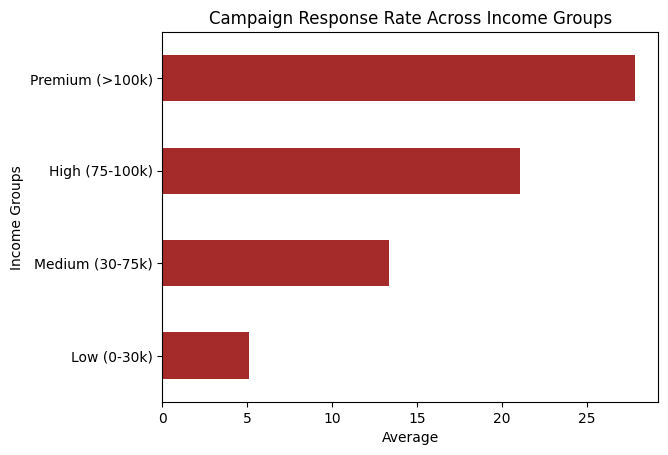

In [68]:
# Response vs INCOME

income_band = pd.cut(df['Income'], bins=[0, 30000, 75000, 100000, df['Income'].max()], 
                     labels=['Low (0-30k)','Medium (30-75k)','High (75-100k)','Premium (>100k)'])

grp_income = df.groupby(income_band)['Response'].mean()*100
print(grp_income)

grp_income.plot(kind='barh',color='brown')
plt.title('Campaign Response Rate Across Income Groups')
plt.ylabel('Income Groups')
plt.xlabel('Average')
plt.show()

Marital_Status
Absurd      18.144611
Alone       23.929748
Divorced    17.479486
Married     11.720006
Single      16.170943
Together    13.653053
Widow       17.683616
YOLO        21.780822
Name: Response, dtype: float64


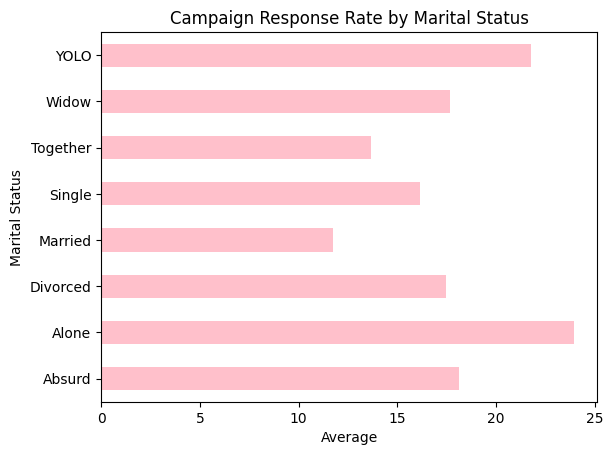

In [69]:
# Response vs MARITAL STATUS

grp_mrst = df.groupby('Marital_Status')['Response'].mean()*100
print(grp_mrst)

grp_mrst.plot(kind='barh',color='pink')
plt.title('Campaign Response Rate by Marital Status')
plt.ylabel('Marital Status')
plt.xlabel('Average')
plt.show()

Education
2n Cycle      11.548776
Basic          9.277857
Graduation    17.299151
Master        14.349478
PhD           13.854225
Name: Response, dtype: float64


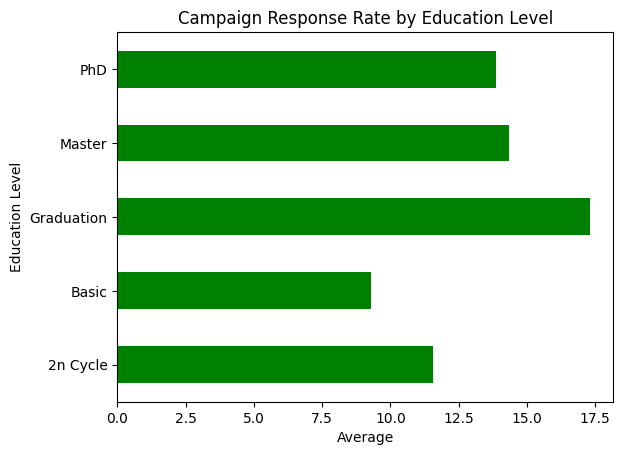

In [70]:
# Response vs EDUCATION

grp_ed = df.groupby('Education')['Response'].mean()*100
print(grp_ed)

grp_ed.plot(kind='barh',color='green')
plt.title('Campaign Response Rate by Education Level')
plt.ylabel('Education Level')
plt.xlabel('Average')
plt.show()

Country
Australia       20.186718
Canada          11.567095
Germany         16.809567
India           18.757790
Mexico          15.200000
Saudi Arabia    14.901449
Spain           12.931809
USA             15.700762
Name: Response, dtype: float64


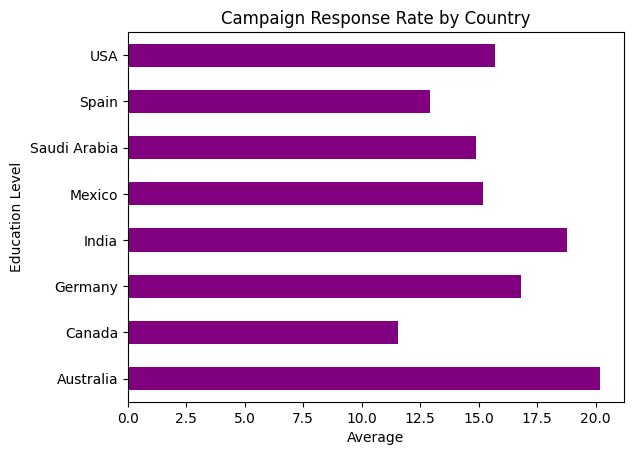

In [71]:
# Response vs COUNTRY

grp_cntry = df.groupby('Country')['Response'].mean()*100
print(grp_cntry)

grp_cntry.plot(kind='barh',color='purple')
plt.title('Campaign Response Rate by Country')
plt.ylabel('Education Level')
plt.xlabel('Average')
plt.show()

### Customer Segmentation

1. INCOME BASED

In [79]:
inc_based_seg = df.groupby(income_band).agg(
    Average_Income=('Income', 'mean'),
    Average_Spending=('Total_Spend', 'mean'),
    Response_Rate=('Response', 'mean'),
    Average_Purchases=('Total_Purchases', 'mean')
)

inc_based_seg['Response_Rate'] *= 100
inc_based_seg

,Average_Income,Average_Spending,Response_Rate,Average_Purchases
Income,,,,
Low (0-30k),12304.335833,194.188395,5.069562,9.238683
Medium (30-75k),53324.446846,580.132710,13.322162,13.221291
High (75-100k),87743.028661,927.319792,21.047581,15.648541
Premium (>100k),107464.966291,1228.287069,27.813659,17.243232


2. AGE BASED

In [80]:
age_based_seg = df.groupby(age_group).agg(
    Average_Income=('Income', 'mean'),
    Average_Spending=('Total_Spend', 'mean'),
    Response_Rate=('Response', 'mean'),
    Average_Purchases=('Total_Purchases', 'mean')
)

age_based_seg['Response_Rate'] *= 100
age_based_seg

,Average_Income,Average_Spending,Response_Rate,Average_Purchases
Age,,,,
Young Adults (18-30),49256.446654,462.302619,10.572260,11.833172
Adults (31-45),52833.360105,508.681199,12.426966,12.463596
Middle-Aged (46-60),55189.630499,611.570213,14.111548,13.003645
Seniors (60+),64231.368689,796.937448,17.796810,14.276019


Customer value increases with age. Seniors (60+) emerge as the most valuable segment, exhibiting the highest average income (₹64,231), average spending (₹796.94), average purchases (14.28), and campaign response rate (17.8%). In contrast, Young Adults (18–30) have the lowest spending and campaign engagement, suggesting that future marketing efforts may yield better returns by prioritizing middle-aged and senior customers.

3. FAMILY BASED

In [81]:
def fam_seg(children):
    if children ==0:
        return 'Single/Couple'   
    elif children == 1:
        return 'Small Family'
    else:
        return 'Large Family'
    
family_seg = df['Children'].apply(fam_seg)

fam_based_seg = df.groupby(family_seg).agg(Average_Income=('Income','mean'),Average_Spending=('Total_Spend','mean'),
                                           Response_Rate=('Response','mean'),Average_Purchase=('Total_Purchases','mean'))
fam_based_seg['Response_Rate'] *= 100
fam_based_seg

,Average_Income,Average_Spending,Response_Rate,Average_Purchase
Children,,,,
Large Family,42871.040970,409.310274,10.103936,11.461493
Single/Couple,76082.920632,942.700304,21.509731,15.580155
Small Family,50985.507148,539.757061,12.290440,12.453179


4. WEB ENGAGEMENT

In [82]:
wb_eng = df.groupby('Web_Visitor_Type').agg(Average_Income=('Income','mean'),Average_Spending=('Total_Spend','mean'),
                                           Response_Rate=('Response','mean'),Average_Purchase=('Total_Purchases','mean'))
wb_eng['Response_Rate'] *= 100
wb_eng

,Average_Income,Average_Spending,Response_Rate,Average_Purchase
Web_Visitor_Type,,,,
Frequent,48626.719022,510.078912,12.072072,12.211278
Moderate,62404.724392,701.879960,16.009558,13.919764
Occasional,74687.223472,929.166979,20.746519,15.205984


5. CAMPAIGN RESPONDERS

In [83]:
def resp(r):
    if r == 1:
        return 'Campaign Responders'
    else:
        return 'Campaign Non Responders'
    
res_seg = df['Response'].apply(resp)

resp_based_Seg = df.groupby(res_seg).agg(Average_Income=('Income','mean'),Average_Spending=('Total_Spend','mean'),
                                           Average_Purchase=('Total_Purchases','mean'))
resp_based_Seg

,Average_Income,Average_Spending,Average_Purchase
Response,,,
Campaign Non Responders,54124.344936,588.571593,12.835152
Campaign Responders,75317.242311,939.294737,15.564791


6. HIGH SPENDERS

In [84]:
import numpy as np
threshold = df['Total_Spend'].quantile(0.90)

df['High_Spender'] = np.where(df['Total_Spend'] > threshold, 'High Spender', "Regular Customer")
hsp_based_seg = df.groupby('High_Spender').agg(Average_Income=('Income','mean'),Average_Spending=('Total_Spend','mean'),
                                           Response_Rate=('Response','mean'),Average_Purchase=('Total_Purchases','mean'))
hsp_based_seg['Response_Rate'] *= 100
hsp_based_seg

,Average_Income,Average_Spending,Response_Rate,Average_Purchase
High_Spender,,,,
High Spender,87841.749491,1972.203965,26.040364,16.925344
Regular Customer,53854.023884,492.378445,13.505684,12.828396


### Correlation Analysis

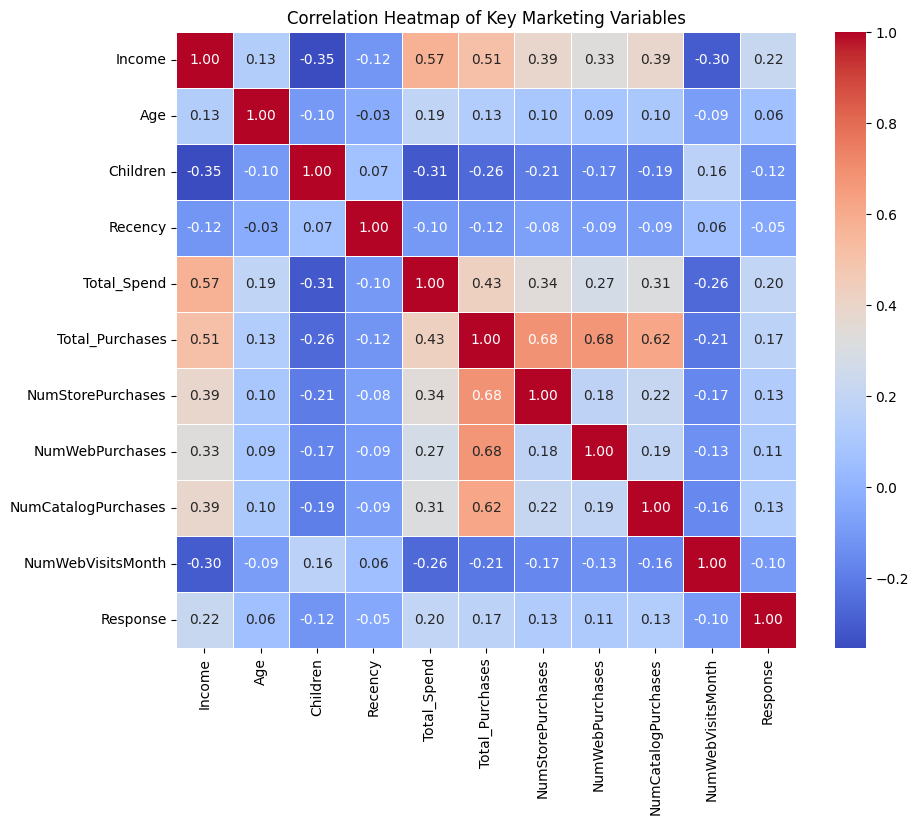

In [85]:
cols = [
    'Income',
    'Age',
    'Children',
    'Recency',
    'Total_Spend',
    'Total_Purchases',
    'NumStorePurchases',
    'NumWebPurchases',
    'NumCatalogPurchases',
    'NumWebVisitsMonth',
    'Response'
]

corr = df[cols].corr()

plt.figure(figsize=(10, 8))

sns.heatmap(
    corr,
    annot=True,
    cmap='coolwarm',
    fmt='.2f',
    linewidths=0.5
)

plt.title("Correlation Heatmap of Key Marketing Variables")
plt.show()

The correlation analysis indicates that Income is one of the strongest drivers of customer value, showing positive relationships with both total spending (0.57) and total purchases (0.51). Customers with higher purchasing activity tend to spend more, while those with more children generally exhibit lower income, spending, and purchase frequency. Interestingly, frequent website visits do not correspond to higher spending, suggesting an opportunity to improve online conversion rates. Campaign response is moderately associated with income and spending, indicating that higher-value customers are more receptive to marketing efforts.

### Customer Profile

In [87]:
customer_profile = df.groupby('Response').agg(
    Avg_Age=('Age', 'mean'),
    Avg_Income=('Income', 'mean'),
    Avg_Total_Spend=('Total_Spend', 'mean'),
    Avg_Children=('Children', 'mean'),
    Avg_Recency=('Recency', 'mean'),
    Avg_Web_Visits=('NumWebVisitsMonth', 'mean'),
    Avg_Web_Purchases=('NumWebPurchases', 'mean'),
    Avg_Store_Purchases=('NumStorePurchases', 'mean'),
    Avg_Catalog_Purchases=('NumCatalogPurchases', 'mean'),
    Customer_Count=('ID', 'count')
).round(2)

customer_profile

,Avg_Age,Avg_Income,Avg_Total_Spend,Avg_Children,Avg_Recency,Avg_Web_Visits,Avg_Web_Purchases,Avg_Store_Purchases,Avg_Catalog_Purchases,Customer_Count
Response,,,,,,,,,,
0,54.02,54124.34,588.57,0.94,63.83,5.27,4.11,4.55,1.98,47735
1,56.13,75317.24,939.29,0.69,59.71,4.58,5.03,5.59,2.84,8265


Responders have higher average income.
Responders spend more overall.
Responders made a more recent purchase (lower recency).
Responders visit the website less often but purchase more, suggesting they are decisive buyers.
Responders have fewer children on average

In [92]:
'''
pd.crosstab() creates a cross-tabulation (contingency table) that shows the relationship between two categorical variables.
normalize='index' -> This converts the counts into row-wise percentages.
'''

print(f"{pd.crosstab(df['Education'],df['Response'],normalize='index') * 100}\n")
print(f"{pd.crosstab(df['Marital_Status'],df['Response'],normalize='index') * 100}\n")
print(f"{pd.crosstab(df['Country'],df['Response'],normalize='index') * 100}\n")


Response            0          1
Education                       
2n Cycle    88.451224  11.548776
Basic       90.722143   9.277857
Graduation  82.700849  17.299151
Master      85.650522  14.349478
PhD         86.145775  13.854225

Response                0          1
Marital_Status                      
Absurd          81.855389  18.144611
Alone           76.070252  23.929748
Divorced        82.520514  17.479486
Married         88.279994  11.720006
Single          83.829057  16.170943
Together        86.346947  13.653053
Widow           82.316384  17.683616
YOLO            78.219178  21.780822

Response              0          1
Country                           
Australia     79.813282  20.186718
Canada        88.432905  11.567095
Germany       83.190433  16.809567
India         81.242210  18.757790
Mexico        84.800000  15.200000
Saudi Arabia  85.098551  14.901449
Spain         87.068191  12.931809
USA           84.299238  15.700762



### Under-Served Customers

Customers who show interest but are not convverting into buyers

1. Number of website visits > 5
2. Low Spending - Less than median of total spend(<50% of the total spend)
3. Did not respond to campaigns

In [93]:
under_served = df[
    (df['NumWebVisitsMonth'] > 5) &
    (df['Total_Spend'] < df['Total_Spend'].median()) &
    (df['Response'] == 0)
]

print(f"Under-served Customers: {len(under_served)}")
print(f"Percentage: {round(len(under_served)/len(df)*100,2)} %")

Under-served Customers: 16765
Percentage: 29.94 %


In [94]:
comparison = pd.DataFrame({
    "Overall": df[['Income','Age','Total_Spend','NumWebVisitsMonth']].mean(),
    "Under-served": under_served[['Income','Age','Total_Spend','NumWebVisitsMonth']].mean()
})

comparison

,Overall,Under-served
Income,57252.189521,32309.417972
Age,54.333304,51.706353
Total_Spend,640.334571,129.781211
NumWebVisitsMonth,5.170107,7.235848


Retarget high-visit, low-spend customers with personalized offers or discounts.
Send reminder emails or notifications to customers who browse frequently but haven't purchased.
Offer product recommendations based on browsing behavior.
Provide first-purchase incentives for customers who have never responded to campaigns.
Test alternative communication channels (SMS, push notifications, social media) for these customers.

Profile of the Under-served Customers

Marital_Status
Married     5407
Together    5271
Single      3352
Divorced    1427
Widow        695
Alone        227
Absurd       195
YOLO         191
Name: count, dtype: int64


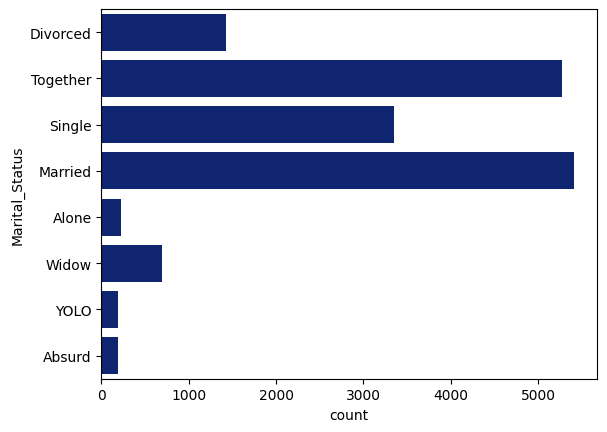

In [95]:
print(under_served['Marital_Status'].value_counts())

sns.countplot(data=under_served,y='Marital_Status')
plt.show()

Education
Graduation    5240
PhD           4230
Master        3132
2n Cycle      2250
Basic         1913
Name: count, dtype: int64


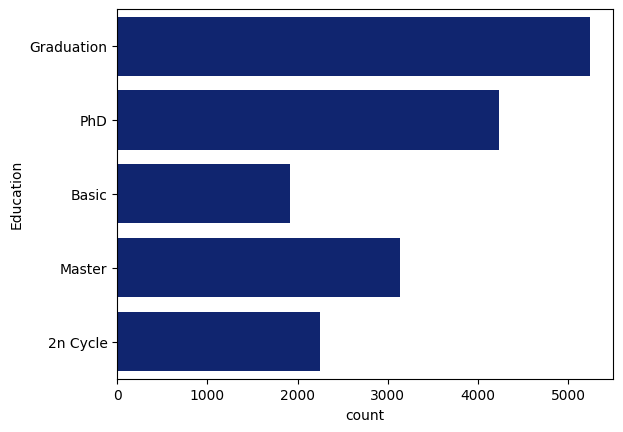

In [96]:
print(under_served['Education'].value_counts())

sns.countplot(data=under_served,y='Education')
plt.show()

Country
Spain           6015
Canada          3440
Saudi Arabia    2442
USA             1256
India           1156
Germany         1126
Australia       1090
Mexico           240
Name: count, dtype: int64


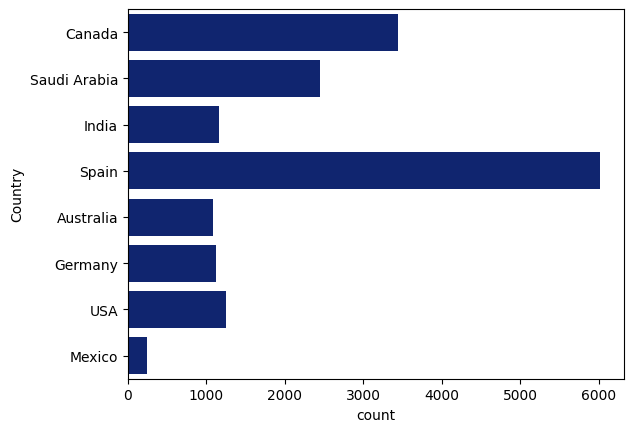

In [97]:
print(under_served['Country'].value_counts())

sns.countplot(data=under_served,y='Country')
plt.show()

               Income  Total_Spend
Income       1.000000     0.507703
Total_Spend  0.507703     1.000000
Income Skewness: 0.7144244118748225
Spending Skewness: 1.0734576977860868


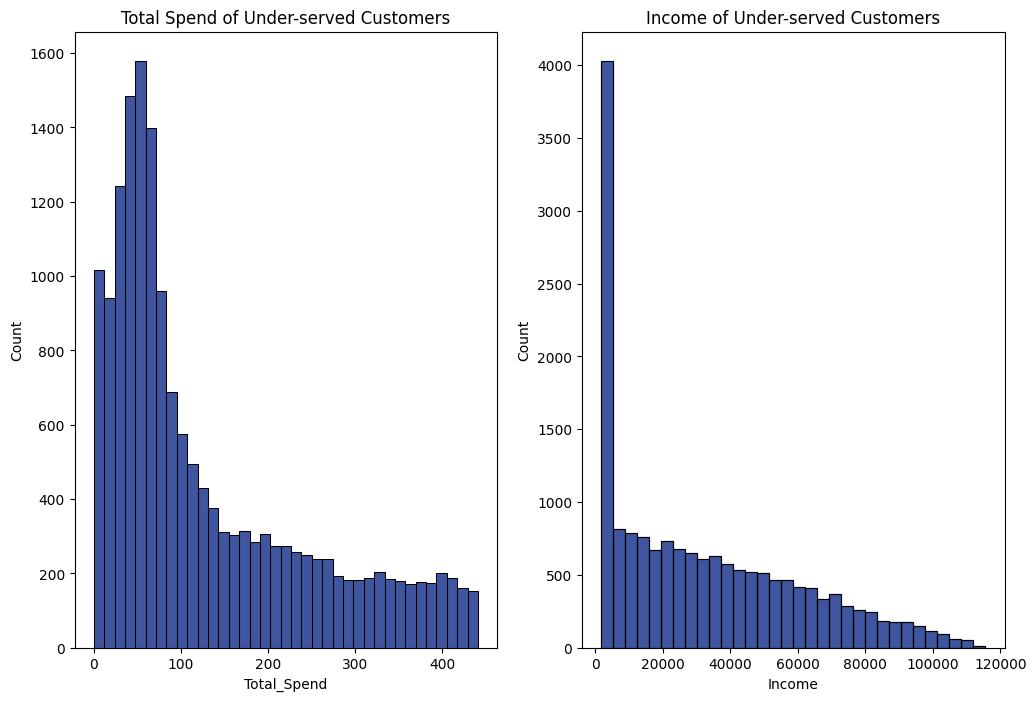

In [111]:
print(under_served[['Income', 'Total_Spend']].corr())
print(f"Income Skewness: {under_served['Income'].skew()}")
print(f"Spending Skewness: {under_served['Total_Spend'].skew()}")

plt.figure(figsize=(12,8))
plt.subplot(1,2,1)
sns.histplot(under_served['Total_Spend'])
plt.title("Total Spend of Under-served Customers")

plt.subplot(1,2,2)
sns.histplot(under_served['Income'])
plt.title("Income of Under-served Customers")

plt.show()

#### Rule Based Segmentation


In [116]:
import numpy as np

df['Income_Segment'] = np.where(df['Income'] > 75000, 'High Income', 'Regular Income')
df['Young_Customer'] = np.where(df['Age'] < 30, 1, 0)
df['Campaign_Responder'] = np.where(df['Response'] == 1, 1, 0)
df['High_Web_Engagement'] = np.where(df['Web_Visitor_Type'] == 'Frequent', 1, 0)
df['Family_Customer'] = np.where(df['Children'] > 0, 1, 0)

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
%store -r df
%store -r dic_df

Exporting Cleaned Dataset

In [118]:
df.to_csv("marketing_data_cleaned.csv", index=False)

### Connecting to MySql

In [1]:
import mysql.connector

connection = mysql.connector.connect(
    host ="localhost",
    user="root",
    password ="1234567"
)
cursor = connection.cursor()
connection.commit()

In [50]:
#Creating Database
q = 'Create Database Marketing_Campaign'
cursor.execute(q)

In [2]:
q = 'USE marketing_campaign'
cursor.execute(q)

In [128]:
# Creating Table

q = '''
CREATE TABLE customers (
    ID INT PRIMARY KEY,
    Year_Birth INT,
    Education VARCHAR(50),
    Marital_Status VARCHAR(50),
    Income DECIMAL(10,2),
    Kidhome INT,
    Teenhome INT,
    Dt_Customer DATE,
    Recency INT,
    MntWines INT,
    MntFruits INT,
    MntMeatProducts INT,
    MntFishProducts INT,
    MntSweetProducts INT,
    MntGoldProds INT,
    NumDealsPurchases INT,
    NumWebPurchases INT,
    NumCatalogPurchases INT,
    NumStorePurchases INT,
    NumWebVisitsMonth INT,
    AcceptedCmp1 TINYINT,
    AcceptedCmp2 TINYINT,
    AcceptedCmp3 TINYINT,
    AcceptedCmp4 TINYINT,
    AcceptedCmp5 TINYINT,
    Response TINYINT,
    Complain TINYINT,
    Country VARCHAR(50),

    Age INT,
    Total_Spend DECIMAL(10,2),
    Total_Purchases INT,
    Children INT,
    Customer_Tenure INT,
    Web_Visitor_Type VARCHAR(50),
    High_Spender VARCHAR(50),
    Income_Segment VARCHAR(50),
    Young_Customer TINYINT,
    Campaign_Responder TINYINT,
    High_Web_Engagement TINYINT,
    Family_Customer TINYINT
)'''

cursor.execute(q)

#### Overall KPIs

In [4]:
# Total Customers
q1 = '''
SELECT COUNT(*) AS Total_Customers
FROM customers
'''
cursor.execute(q1)

for data in cursor:
    print(data)

# Average Income    
q2 = '''
SELECT ROUND(AVG(Income),2) AS Avg_Income
FROM customers
'''
cursor.execute(q2)

for data in cursor:
    print(data)

# Average Spending
q3 = '''
SELECT ROUND(AVG(Total_Spend),2) AS Avg_Spending
FROM customers
'''
cursor.execute(q3)

for data in cursor:
    print(data)

# Campaign Response Rate
q4 = '''
SELECT ROUND(AVG(Response)*100,2) AS Response_Rate
FROM customers
'''
cursor.execute(q4)

for data in cursor:
    print(data)

# Total Revenue

q5 = '''
SELECT SUM(Total_Spend) AS Total_Revenue
FROM customers
'''
cursor.execute(q5)

for data in cursor:
    print(data)

(56000,)
(Decimal('57252.19'),)
(Decimal('640.33'),)
(Decimal('14.76'),)
(Decimal('35858736.00'),)


In [9]:
%store -r df

#### Customer Demographics

AGE ANALYSIS

In [ ]:
# Average Age of Customers

q1 = '''
    SELECT ROUND(AVG(Age),2) AS Avg_Age
    FROM customers
'''
cursor.execute(q1)

for data in cursor:
    print(data)

(Decimal('54.33'),)


In [ ]:
# Age Group

q2 = '''
    SELECT 
    CASE
        WHEN Age < 30 THEN 'Young'
        WHEN Age BETWEEN 30 AND 50 THEN 'Middle'
        ELSE 'Senior'
    END AS Age_Group,
    COUNT(*) AS Customers
    FROM customers
    GROUP BY Age_Group
'''
cursor.execute(q2)

for data in cursor:
    print(data)


('Senior', 32905)
('Middle', 23095)


EDUCATION ANALYSIS

In [ ]:
# Which education group spends the most?

q3 = '''
    SELECT Education, ROUND(AVG(Total_Spend),2) AS Avg_Spend
    FROM customers
    GROUP BY Education
    ORDER BY Avg_Spend DESC
'''
cursor.execute(q3)

for data in cursor:
    print(data)

('Graduation', Decimal('747.35'))
('Master', Decimal('648.50'))
('PhD', Decimal('575.67'))
('2n Cycle', Decimal('511.30'))
('Basic', Decimal('416.46'))


In [22]:
# Which education group responds the most?

q4 = '''
    SELECT Education, ROUND(AVG(Response)*100,2) AS Response_Rate
    FROM customers
    GROUP BY Education
    ORDER BY Response_Rate DESC
'''
cursor.execute(q4)

for data in cursor:
    print(data)

('Graduation', Decimal('17.30'))
('Master', Decimal('14.35'))
('PhD', Decimal('13.85'))
('2n Cycle', Decimal('11.55'))
('Basic', Decimal('9.28'))


MARITAL STATUS ANALYSIS

In [23]:
# Which marital status spends the most?

q5 = '''
    SELECT Marital_Status, ROUND(AVG(Total_Spend),2) AS Avg_Spend
    FROM customers
    GROUP BY Marital_Status
    ORDER BY Avg_Spend DESC
'''
cursor.execute(q5)

for data in cursor:
    print(data)

('Divorced', Decimal('753.91'))
('Widow', Decimal('745.05'))
('Alone', Decimal('701.29'))
('Single', Decimal('688.19'))
('YOLO', Decimal('665.59'))
('Absurd', Decimal('655.35'))
('Together', Decimal('644.77'))
('Married', Decimal('504.91'))


In [25]:
# Which marital status responds best?

q6 = '''
    SELECT Marital_Status, ROUND(AVG(Response)*100,2) AS Response_Rate
    FROM customers
    GROUP BY Marital_Status
    ORDER BY Response_Rate DESC
'''
cursor.execute(q6)

for data in cursor:
    print(data)

('Alone', Decimal('23.93'))
('YOLO', Decimal('21.78'))
('Absurd', Decimal('18.14'))
('Widow', Decimal('17.68'))
('Divorced', Decimal('17.48'))
('Single', Decimal('16.17'))
('Together', Decimal('13.65'))
('Married', Decimal('11.72'))


COUNTRY ANALYSIS

In [28]:
# Which country generates the highest revenue?

q7 = '''
    SELECT Country, ROUND(SUM(Total_Spend),2) AS Total_Revenue
    FROM customers
    GROUP BY Country
    ORDER BY Total_Revenue DESC
'''
cursor.execute(q7)

for data in cursor:
    print(data)

('Spain', Decimal('9309820.00'))
('Canada', Decimal('6289869.00'))
('Saudi Arabia', Decimal('5512798.00'))
('Australia', Decimal('4697029.00'))
('India', Decimal('3484625.00'))
('Germany', Decimal('3134473.00'))
('USA', Decimal('2875247.00'))
('Mexico', Decimal('554875.00'))


In [ ]:
# Which country has the highest response rate?

q8 = '''
    SELECT Country, ROUND(AVG(Response)*100,2) AS Response_Rate
    FROM customers
    GROUP BY Country
    ORDER BY Response_Rate DESC
'''  
cursor.execute(q8)

for data in cursor:
    print(data)

('Australia', Decimal('20.19'))
('India', Decimal('18.76'))
('Germany', Decimal('16.81'))
('USA', Decimal('15.70'))
('Mexico', Decimal('15.20'))
('Saudi Arabia', Decimal('14.90'))
('Spain', Decimal('12.93'))
('Canada', Decimal('11.57'))


#### Spending Analysis

In [ ]:
# Average spending by country

q1 = '''
    SELECT Country, ROUND(AVG(Total_Spend),2) AS Avg_Spend
    FROM customers
    GROUP BY Country
    ORDER BY Avg_Spend DESC
'''
cursor.execute(q1)

for data in cursor:
    print(data)

('Australia', Decimal('827.38'))
('India', Decimal('723.85'))
('Germany', Decimal('707.24'))
('USA', Decimal('663.88'))
('Saudi Arabia', Decimal('654.57'))
('Mexico', Decimal('634.14'))
('Canada', Decimal('585.32'))
('Spain', Decimal('557.37'))


In [ ]:
# Average spending by education

q2 = '''
    SELECT Education, ROUND(AVG(Total_Spend),2) AS Avg_Spend
    FROM customers
    GROUP BY Education
    ORDER BY Avg_Spend DESC
'''
cursor.execute(q2)

for data in cursor:
    print(data)

('Graduation', Decimal('747.35'))
('Master', Decimal('648.50'))
('PhD', Decimal('575.67'))
('2n Cycle', Decimal('511.30'))
('Basic', Decimal('416.46'))


In [32]:
# Average spending by marital status

q3 = '''
    SELECT Marital_Status, ROUND(AVG(Total_Spend),2) AS Avg_Spend
    FROM customers
    GROUP BY Marital_Status
    ORDER BY Avg_Spend DESC
'''
cursor.execute(q3)

for data in cursor:
    print(data)

('Divorced', Decimal('753.91'))
('Widow', Decimal('745.05'))
('Alone', Decimal('701.29'))
('Single', Decimal('688.19'))
('YOLO', Decimal('665.59'))
('Absurd', Decimal('655.35'))
('Together', Decimal('644.77'))
('Married', Decimal('504.91'))


In [33]:
# Average spending by age group

q4 = '''
    SELECT 
    CASE
        WHEN Age < 30 THEN 'Young'
        WHEN Age BETWEEN 30 AND 50 THEN 'Middle'
        ELSE 'Senior'
    END AS Age_Group,
    ROUND(AVG(Total_Spend),2) AS Avg_Spend
    FROM customers
    GROUP BY Age_Group
    ORDER BY Avg_Spend DESC
'''
cursor.execute(q4)

for data in cursor:
    print(data)

('Senior', Decimal('714.22'))
('Middle', Decimal('535.06'))


In [36]:
# Highest spending product category

q5='''
    SELECT 'Wines' AS Product, SUM(MntWines) AS Total_Spending
    FROM customers

    UNION ALL

    SELECT 'Fruits' AS Product, SUM(MntFruits) AS Total_Spending
    FROM customers

    UNION ALL

    SELECT 'Meat Products' AS Product, SUM(MntMeatProducts) AS Total_Spending
    FROM customers

    UNION ALL

    SELECT 'Fish Products' AS Product, SUM(MntFishProducts) AS Total_Spending
    FROM customers
    
    UNION ALL

    SELECT 'Sweet Products' AS Product, SUM(MntSweetProducts) AS Total_Spending
    FROM customers

    UNION ALL

    SELECT 'Gold Products' AS Product, SUM(MntGoldProds) AS Total_Spending
    FROM customers

    ORDER BY Total_Spending DESC
'''
cursor.execute(q5)

for data in cursor:
    print(data)

('Meat Products', Decimal('15024465'))
('Wines', Decimal('13830963'))
('Fish Products', Decimal('2861473'))
('Gold Products', Decimal('1981595'))
('Sweet Products', Decimal('1255691'))
('Fruits', Decimal('904549'))


#### Campaign Analysis

In [41]:
# Overall response rate

q1 ='''
    SELECT ROUND(AVG(Response)*100,2) AS Overall_Response_Rate
    FROM customers
'''
cursor.execute(q1)

for data in cursor:
    print(data)

(Decimal('14.76'),)


In [78]:
# Which campaign perfomed the best?

q2 = '''
    SELECT 'Campaign 1' AS Campaign, ROUND(AVG(AcceptedCmp1)*100,2) AS Avg_Campaign_Response
    FROM customers

    UNION ALL

    SELECT 'Campaign 2' AS Campaign, ROUND(AVG(AcceptedCmp2)*100,2) AS Avg_Campaign_Response
    FROM customers

    UNION ALL

    SELECT 'Campaign 3' AS Campaign, ROUND(AVG(AcceptedCmp3)*100,2) AS Avg_Campaign_Response
    FROM customers

    UNION ALL

    SELECT 'Campaign 4' AS Campaign, ROUND(AVG(AcceptedCmp4)*100,2) AS Avg_Campaign_Response
    FROM customers

    UNION ALL

    SELECT 'Campaign 5' AS Campaign, ROUND(AVG(AcceptedCmp5)*100,2) AS Avg_Campaign_Response
    FROM customers

    ORDER BY Avg_Campaign_Response DESC
'''
cursor.execute(q2)

for data in cursor:
    print(data)

('Campaign 1', Decimal('13.44'))
('Campaign 3', Decimal('6.24'))
('Campaign 4', Decimal('5.68'))
('Campaign 5', Decimal('4.57'))
('Campaign 2', Decimal('1.44'))


In [51]:
# Which education group responds the most?

q3 = '''
    SELECT Education, COUNT(*) AS Total_Customers, 
           SUM(Response) AS Responders, ROUND(AVG(Response)*100,2) AS Response_Rate
    FROM customers
    GROUP BY Education
    ORDER BY Response_Rate DESC
'''
cursor.execute(q3)

for data in cursor:
    print(data)

('Graduation', 22741, Decimal('3934'), Decimal('17.30'))
('Master', 10530, Decimal('1511'), Decimal('14.35'))
('PhD', 12581, Decimal('1743'), Decimal('13.85'))
('2n Cycle', 5966, Decimal('689'), Decimal('11.55'))
('Basic', 4182, Decimal('388'), Decimal('9.28'))


In [53]:
# Which country responds the most?

q4 = '''
    SELECT Country, COUNT(*) AS Total_Customers,
           SUM(Response) AS Responders, ROUND(AVG(Response)*100,2) AS Response_Rate
    FROM customers
    GROUP BY Country
    ORDER BY Response_Rate DESC
'''
cursor.execute(q4)

for data in cursor:
    print(data)

('Australia', 5677, Decimal('1146'), Decimal('20.19'))
('India', 4814, Decimal('903'), Decimal('18.76'))
('Germany', 4432, Decimal('745'), Decimal('16.81'))
('USA', 4331, Decimal('680'), Decimal('15.70'))
('Mexico', 875, Decimal('133'), Decimal('15.20'))
('Saudi Arabia', 8422, Decimal('1255'), Decimal('14.90'))
('Spain', 16703, Decimal('2160'), Decimal('12.93'))
('Canada', 10746, Decimal('1243'), Decimal('11.57'))


In [59]:
# Which marital status responds the most?

q5 = '''
    SELECT Marital_Status, COUNT(*) AS Total_Customers,
           SUM(Response) AS Responders, ROUND(AVG(Response)*100,2) AS Response_Rate
    FROM customers
    GROUP BY Marital_Status
    ORDER BY Response_Rate DESC
'''
cursor.execute(q5)

for data in cursor:
    print(data)

('Alone', 911, Decimal('218'), Decimal('23.93'))
('YOLO', 730, Decimal('159'), Decimal('21.78'))
('Absurd', 733, Decimal('133'), Decimal('18.14'))
('Widow', 3540, Decimal('626'), Decimal('17.68'))
('Divorced', 6459, Decimal('1129'), Decimal('17.48'))
('Single', 12238, Decimal('1979'), Decimal('16.17'))
('Together', 17703, Decimal('2417'), Decimal('13.65'))
('Married', 13686, Decimal('1604'), Decimal('11.72'))


In [60]:
# Which income band responds the most?

q6 = '''
    SELECT
    CASE
        WHEN Income < 30000 THEN 'Low Income'
        WHEN Income BETWEEN 30000 AND 60000 THEN 'Medium Income'
        WHEN Income BETWEEN 60000 AND 75000 THEN 'Upper Middle'
        ELSE 'High Income'
    END AS Income_Band,
    COUNT(*) AS Customers,
    ROUND(AVG(Response)*100,2) AS Response_Rate
    FROM customers
    GROUP BY Income_Band
    ORDER BY Response_Rate DESC
'''
cursor.execute(q6)

for data in cursor:
    print(data)

('High Income', 19782, Decimal('23.54'))
('Upper Middle', 7620, Decimal('16.15'))
('Medium Income', 13863, Decimal('11.77'))
('Low Income', 14735, Decimal('5.07'))


In [ ]:
# Which Age group responds the most?

q7 = '''
    SELECT
    CASE
        WHEN Age < 30 THEN 'Young'
        WHEN Age BETWEEN 30 AND 50 THEN 'Middle'
        ELSE 'Senior'
    END AS Age_Group,
    COUNT(*) AS Customers,
    ROUND(AVG(Response)*100,2) AS Response_Rate
    FROM customers
    GROUP BY Age_Group
    ORDER BY Response_Rate DESC
'''
cursor.execute(q7)

for data in cursor:
    print(data)

('Senior', 32905, Decimal('16.07'))
('Middle', 23095, Decimal('12.89'))


RESPONDERS VS NON RESPONDERS

In [65]:
# What are the characteristics of the customers who accepted the campaign?

q8 = '''
    SELECT Response,
        ROUND(AVG(Age),1) AS Avg_Age,
        ROUND(AVG(Income),2) AS Avg_Income,
        ROUND(AVG(Total_Spend),2) AS Avg_Spend,
        ROUND(AVG(Children),2) AS Avg_Children,
        ROUND(AVG(Recency),2) AS Avg_Recency
    FROM customers
    GROUP BY Response
'''
cursor.execute(q8)

for data in cursor:
    print(data)

(0, Decimal('54.0'), Decimal('54124.34'), Decimal('588.57'), Decimal('0.94'), Decimal('63.83'))
(1, Decimal('56.1'), Decimal('75317.24'), Decimal('939.29'), Decimal('0.69'), Decimal('59.71'))


In [69]:
# What products do campaign responders spend on?

q9 = '''
    SELECT Response,
        ROUND(AVG(MntWines),2) AS Wine,
        ROUND(AVG(MntFruits),2) AS Fruits,
        ROUND(AVG(MntMeatProducts),2) AS Meat,
        ROUND(AVG(MntFishProducts),2) AS Fish,
        ROUND(AVG(MntSweetProducts),2) AS Sweets,
        ROUND(AVG(MntGoldProds),2) AS Gold
    FROM customers
    GROUP BY Response
'''
cursor.execute(q9)

for data in cursor:
    print(data)

(0, Decimal('223.78'), Decimal('14.36'), Decimal('251.01'), Decimal('46.64'), Decimal('20.15'), Decimal('32.63'))
(1, Decimal('380.99'), Decimal('26.48'), Decimal('368.12'), Decimal('76.85'), Decimal('35.54'), Decimal('51.30'))


In [71]:
# Which purchase channels are preferred by campaign responders?

q10 = '''
    SELECT Response,
        ROUND(AVG(NumDealsPurchases),2) AS Deals,
        ROUND(AVG(NumWebPurchases),2) AS Web,
        ROUND(AVG(NumCatalogPurchases),2) AS Catalog,
        ROUND(AVG(NumStorePurchases),2) AS Store,
        ROUND(AVG(NumWebVisitsMonth),2) AS Web_Visits
    FROM customers
    GROUP BY Response
'''
cursor.execute(q10)

for data in cursor:
    print(data)

(0, Decimal('2.18'), Decimal('4.11'), Decimal('1.98'), Decimal('4.55'), Decimal('5.27'))
(1, Decimal('2.10'), Decimal('5.03'), Decimal('2.84'), Decimal('5.59'), Decimal('4.58'))


In [72]:
# Top 10 highest spending responders

q11 = '''
    SELECT ID, Country, Education, Income, Total_Spend
    FROM customers
    WHERE Response = 1
    ORDER BY Total_Spend DESC
    LIMIT 10
'''
cursor.execute(q11)

for data in cursor:
    print(data)

(13759135, 'Australia', 'PhD', Decimal('114183.70'), Decimal('3338.00'))
(14059885, 'Spain', 'Graduation', Decimal('85036.20'), Decimal('3234.00'))
(2837885, 'Saudi Arabia', 'PhD', Decimal('116832.60'), Decimal('3203.00'))
(2295475, 'Canada', 'PhD', Decimal('111109.40'), Decimal('3201.00'))
(16350586, 'Australia', 'Graduation', Decimal('113123.00'), Decimal('3186.00'))
(12277380, 'India', 'Master', Decimal('106972.90'), Decimal('3185.00'))
(4581160, 'Mexico', 'Graduation', Decimal('106055.00'), Decimal('3180.00'))
(9692517, 'Spain', 'Graduation', Decimal('112181.60'), Decimal('3170.00'))
(10082330, 'Spain', 'Graduation', Decimal('109114.60'), Decimal('3166.00'))
(10896224, 'Canada', 'PhD', Decimal('64515.90'), Decimal('3142.00'))


In [74]:
# Campaign Accepted Summary

q12 = '''
    SELECT
        (AcceptedCmp1+AcceptedCmp2+AcceptedCmp3+AcceptedCmp4+AcceptedCmp5) AS Campaigns_Accepted,
        COUNT(*) AS Customers
    FROM customers
    GROUP BY Campaigns_Accepted
    ORDER BY Campaigns_Accepted
'''
cursor.execute(q12)

for data in cursor:
    print(data)

(0, 40883)
(1, 12864)
(2, 2066)
(3, 175)
(4, 12)


#### Channel Analysis

In [8]:
# Average number of purchases made through each channel
# Which purchase channel is most commonly used?

q1 = '''
    SELECT ROUND(AVG(NumWebPurchases),2) AS Avg_Web_Purchases,
           ROUND(AVG(NumDealsPurchases),2) AS Avg_Deals_Purchases,
           ROUND(AVG(NumCatalogPurchases),2) AS Avg_Catalog_Purchases,
           ROUND(AVG(NumStorePurchases),2) AS Avg_Store_Purchases
    FROM customers
'''
cursor.execute(q1)

for data in cursor:
    print(data)

(Decimal('4.25'), Decimal('2.17'), Decimal('2.11'), Decimal('4.71'))


In [ ]:
# Overall usage of each channel
# Which channel contributes the highest number of purchases?

q2 = '''
    SELECT SUM(NumWebPurchases) AS Total_Web_Purchases,
           SUM(NumDealsPurchases) AS Total_Deals_Purchases,
           SUM(NumCatalogPurchases) AS Total_Catalog_Purchases,
           SUM(NumStorePurchases) AS Total_Store_Purchases
    FROM customers
'''
cursor.execute(q2)

for data in cursor:
    print(data)

(Decimal('237938'), Decimal('121630'), Decimal('118202'), Decimal('263559'))


In [11]:
# Average monthly web visits

q3 = '''
    SELECT ROUND(AVG(NumWebVisitsMonth),2) AS Avg_Web_Visits
    FROM customers
'''
cursor.execute(q3)

for data in cursor:
    print(data)

(Decimal('5.17'),)


In [14]:
# Website visits by campaign response
# Do campaign responders visit the website more frequently?

q4 = '''
    SELECT
    CASE
        WHEN Response = 1 THEN 'Responded'
        ELSE 'Not Responded'
    END AS Campaign_Response,
    ROUND(AVG(NumWebVisitsMonth),2) AS Avg_Web_Visits
    FROM customers
    GROUP BY Campaign_Response
'''
cursor.execute(q4)

for data in cursor:
    print(data)

('Not Responded', Decimal('5.27'))
('Responded', Decimal('4.58'))


In [20]:
# Channel usage by high spenders
# Which channel is preferred by high spenders?

q5 = '''
    SELECT High_Spender AS Customer_Type, ROUND(AVG(NumWebVisitsMonth),2) AS Avg_Web,
           ROUND(AVG(NumDealsPurchases),2) AS Avg_Deals,
           ROUND(AVG(NumCatalogPurchases),2) AS Avg_Catalog,
           ROUND(AVG(NumStorePurchases),2) AS Avg_Store
    FROM customers
    GROUP BY Customer_Type
'''
cursor.execute(q5)

for data in cursor:
    print(data)

('Regular Customer', Decimal('5.30'), Decimal('2.19'), Decimal('1.99'), Decimal('4.53'))
('High Spender', Decimal('4.04'), Decimal('1.98'), Decimal('3.20'), Decimal('6.29'))


In [22]:
# Channel usage by income group

q6 = '''
    SELECT
    CASE
        WHEN Income < 30000 THEN 'Low Income'
        WHEN Income BETWEEN 30000 AND 60000 THEN 'Medium Income'
        WHEN Income BETWEEN 60000 AND 75000 THEN 'Upper Middle'
        ELSE 'High Income'
    END AS Income_Band,
    ROUND(AVG(NumDealsPurchases),2) AS Avg_Deals,
    ROUND(AVG(NumWebPurchases),2) AS Avg_Web,
    ROUND(AVG(NumCatalogPurchases),2) AS Avg_Catalog,
    ROUND(AVG(NumStorePurchases),2) AS Avg_Store
    FROM customers
    GROUP BY Income_Band
'''
cursor.execute(q6)

for data in cursor:
    print(data)

('Low Income', Decimal('2.26'), Decimal('2.88'), Decimal('0.90'), Decimal('3.19'))
('High Income', Decimal('2.04'), Decimal('5.23'), Decimal('3.08'), Decimal('5.88'))
('Medium Income', Decimal('2.25'), Decimal('4.08'), Decimal('1.86'), Decimal('4.42'))
('Upper Middle', Decimal('2.19'), Decimal('4.64'), Decimal('2.40'), Decimal('5.11'))


In [ ]:
# Web visits by income group

q7 = '''
    SELECT
    CASE
        WHEN Income < 30000 THEN 'Low Income'
        WHEN Income BETWEEN 30000 AND 60000 THEN 'Medium Income'
        WHEN Income BETWEEN 60000 AND 75000 THEN 'Upper Middle'
        ELSE 'High Income'
    END AS Income_Band,
    ROUND(AVG(NumWebVisitsMonth),2) AS Avg_Web_Visits
    FROM customers
    GROUP BY Income_Band
'''
cursor.execute(q7)

for data in cursor:
    print(data)

('Low Income', Decimal('6.17'))
('High Income', Decimal('4.34'))
('Medium Income', Decimal('5.39'))
('Upper Middle', Decimal('5.00'))


In [25]:
# Channel usage by country

q8 = '''
    SELECT Country, ROUND(AVG(NumDealsPurchases),2) AS Avg_Deals,
           ROUND(AVG(NumWebPurchases),2) AS Avg_Web,
           ROUND(AVG(NumCatalogPurchases),2) AS Avg_Catalog,
           ROUND(AVG(NumStorePurchases),2) AS Avg_Store
    FROM customers
    GROUP BY Country
'''
cursor.execute(q8)

for data in cursor:
    print(data)

('India', Decimal('2.21'), Decimal('4.75'), Decimal('2.27'), Decimal('5.03'))
('Mexico', Decimal('2.22'), Decimal('4.14'), Decimal('1.94'), Decimal('4.72'))
('Canada', Decimal('2.17'), Decimal('4.08'), Decimal('1.94'), Decimal('4.59'))
('Spain', Decimal('2.16'), Decimal('3.97'), Decimal('1.90'), Decimal('4.40'))
('USA', Decimal('2.20'), Decimal('4.24'), Decimal('2.27'), Decimal('5.05'))
('Australia', Decimal('2.07'), Decimal('4.66'), Decimal('2.53'), Decimal('5.01'))
('Germany', Decimal('2.10'), Decimal('4.55'), Decimal('2.30'), Decimal('4.83'))
('Saudi Arabia', Decimal('2.25'), Decimal('4.31'), Decimal('2.21'), Decimal('4.84'))


In [30]:
# Website visits vs spending
# Does high website engagement lead to higher spending?

q9 = '''
    SELECT
    CASE
        WHEN High_Web_Engagement = 1 THEN 'High Web Engagement'
        ELSE 'Low Web Engagement'
    END AS Engagement,
    ROUND(AVG(Total_Spend),2) AS Avg_Spending
    FROM customers
    GROUP BY Engagement
'''
cursor.execute(q9)

for data in cursor:
    print(data)

('Low Web Engagement', Decimal('790.31'))
('High Web Engagement', Decimal('510.08'))


In [32]:
# Identifying under-served customers
# Which customer should be targeted with personalized offers?

q10 = '''
    SELECT ID, Income, Total_Spend, NumWebVisitsMonth, Response
    FROM customers
    WHERE NumWebVisitsMonth > 5 AND Response = 0 AND 
          Total_Spend < (SELECT AVG(Total_Spend) FROM customers)
'''
cursor.execute(q10)

for data in cursor:
    print(data)

(830, Decimal('1730.00'), Decimal('29.00'), 8, 0)
(1181, Decimal('43106.20'), Decimal('8.00'), 8, 0)
(2312, Decimal('1730.00'), Decimal('0.00'), 8, 0)
(2667, Decimal('1730.00'), Decimal('77.00'), 8, 0)
(5857, Decimal('12120.70'), Decimal('226.00'), 7, 0)
(8832, Decimal('49928.30'), Decimal('35.00'), 8, 0)
(9085, Decimal('3315.80'), Decimal('16.00'), 8, 0)
(9143, Decimal('31494.90'), Decimal('53.00'), 6, 0)
(9281, Decimal('14898.20'), Decimal('57.00'), 8, 0)
(10343, Decimal('52499.70'), Decimal('605.00'), 6, 0)
(11357, Decimal('60046.90'), Decimal('227.00'), 6, 0)
(12047, Decimal('38559.00'), Decimal('159.00'), 8, 0)
(12512, Decimal('91204.60'), Decimal('121.00'), 7, 0)
(13874, Decimal('31487.00'), Decimal('10.00'), 8, 0)
(14896, Decimal('108209.20'), Decimal('590.00'), 6, 0)
(18534, Decimal('57506.40'), Decimal('68.00'), 7, 0)
(19717, Decimal('1730.00'), Decimal('52.00'), 7, 0)
(19771, Decimal('94995.90'), Decimal('476.00'), 6, 0)
(20184, Decimal('39505.40'), Decimal('538.00'), 6, 0)
(

#### Segmentation

In [55]:
# Income Segment

q1 = '''
    SELECT
    CASE
        WHEN Income < 30000 THEN 'Low Income'
        WHEN Income BETWEEN 30000 AND 60000 THEN 'Medium Income'
        WHEN Income BETWEEN 60000 AND 75000 THEN 'Upper Middle'
        ELSE 'High Income'
    END AS Income_Band,
    COUNT(*) AS Total_Customers,
    ROUND(AVG(Age),1) AS Avg_Age,
    ROUND(AVG(Total_Spend),2) AS Avg_Spend,
    ROUND(AVG(Response)*100,2) AS Response_Rate,
    ROUND(AVG(Total_Purchases),2) AS Avg_Purchases
    FROM customers
    GROUP BY Income_Band
'''
cursor.execute(q1)

for data in cursor:
    print(data)

('Low Income', 14735, Decimal('52.1'), Decimal('194.19'), Decimal('5.07'), Decimal('9.24'))
('High Income', 19782, Decimal('56.0'), Decimal('1038.03'), Decimal('23.54'), Decimal('16.24'))
('Medium Income', 13863, Decimal('53.9'), Decimal('500.48'), Decimal('11.77'), Decimal('12.61'))
('Upper Middle', 7620, Decimal('55.0'), Decimal('725.05'), Decimal('16.15'), Decimal('14.33'))


In [56]:
# Age Segment

q2 = '''
    SELECT
    CASE
        WHEN Age < 30 THEN 'Young'
        WHEN Age BETWEEN 30 AND 50 THEN 'Middle Age'
        ELSE 'Senior'
    END AS Age_Group,
    COUNT(*) AS Total_Customers,
    ROUND(AVG(Income),2) AS Avg_Income,
    ROUND(AVG(Total_Spend),2) AS Avg_Spend,
    ROUND(AVG(Response)*100,2) AS Response_Rate,
    ROUND(AVG(Total_Purchases),2) AS Avg_Purchases
    FROM customers
    GROUP BY Age_Group
'''
cursor.execute(q2)

for data in cursor:
    print(data)

('Senior', 32905, Decimal('60170.57'), Decimal('714.22'), Decimal('16.07'), Decimal('13.72'))
('Middle Age', 23095, Decimal('53094.18'), Decimal('535.06'), Decimal('12.89'), Decimal('12.54'))


In [58]:
# Family Segment

q3 = '''
    SELECT
    CASE
        WHEN Children > 0 THEN 'Family Customer'
        ELSE 'No Children'
    END AS Family_Type,
    COUNT(*) AS Total_Customers,
    ROUND(AVG(Income),2) AS Avg_Income,
    ROUND(AVG(Total_Spend),2) AS Avg_Spend,
    ROUND(AVG(Response)*100,2) AS Response_Rate,
    ROUND(AVG(Total_Purchases),2) AS Avg_Purchases
    FROM customers
    GROUP BY Family_Type
'''
cursor.execute(q3)

for data in cursor:
    print(data)

('Family Customer', 38222, Decimal('48493.55'), Decimal('499.70'), Decimal('11.62'), Decimal('12.15'))
('No Children', 17778, Decimal('76082.92'), Decimal('942.70'), Decimal('21.51'), Decimal('15.58'))


In [59]:
# High Web Engagement

q4 = '''
    SELECT
    CASE
        WHEN High_Web_Engagement = 1 THEN 'High Web Engagement'
        ELSE 'Low Web Engagement'
    END AS Web_Engagement,
    COUNT(*) AS Total_Customers,
    ROUND(AVG(Age),1) AS Avg_Age,
    ROUND(AVG(Income),2) AS Avg_Income,
    ROUND(AVG(Total_Spend),2) AS Avg_Spend,
    ROUND(AVG(Response)*100,2) AS Response_Rate,
    ROUND(AVG(Total_Purchases),2) AS Avg_Purchases
    FROM customers
    GROUP BY Web_Engagement
'''
cursor.execute(q4)

for data in cursor:
    print(data)

('Low Web Engagement', 26030, Decimal('55.4'), Decimal('67183.24'), Decimal('790.31'), Decimal('17.85'), Decimal('14.42'))
('High Web Engagement', 29970, Decimal('53.5'), Decimal('48626.72'), Decimal('510.08'), Decimal('12.07'), Decimal('12.21'))


In [60]:
# High Spender

q5 = '''
    SELECT High_Spender,
    COUNT(*) AS Total_Customers,
    ROUND(AVG(Age),1) AS Avg_Age,
    ROUND(AVG(Income),2) AS Avg_Income,
    ROUND(AVG(Total_Spend),2) AS Avg_Spend,
    ROUND(AVG(Response)*100,2) AS Response_Rate,
    ROUND(AVG(Total_Purchases),2) AS Avg_Purchases
    FROM customers
    GROUP BY High_Spender
'''
cursor.execute(q5)

for data in cursor:
    print(data)

('Regular Customer', 50401, Decimal('53.9'), Decimal('53854.02'), Decimal('492.38'), Decimal('13.51'), Decimal('12.83'))
('High Spender', 5599, Decimal('58.3'), Decimal('87841.75'), Decimal('1972.20'), Decimal('26.04'), Decimal('16.93'))


In [61]:
# Campaign Responders

q6 = '''
    SELECT
    CASE
        WHEN Response = 1 THEN 'Responders'
        ELSE 'Non Responders'
    END AS Campaign_Status,
    COUNT(*) AS Total_Customers,
    ROUND(AVG(Age),1) AS Avg_Age,
    ROUND(AVG(Income),2) AS Avg_Income,
    ROUND(AVG(Total_Spend),2) AS Avg_Spend,
    ROUND(AVG(Response)*100,2) AS Response_Rate,
    ROUND(AVG(Total_Purchases),2) AS Avg_Purchases
    FROM customers
    GROUP BY Campaign_Status
'''
cursor.execute(q6)

for data in cursor:
    print(data)

('Non Responders', 47735, Decimal('54.0'), Decimal('54124.34'), Decimal('588.57'), Decimal('0.00'), Decimal('12.84'))
('Responders', 8265, Decimal('56.1'), Decimal('75317.24'), Decimal('939.29'), Decimal('100.00'), Decimal('15.56'))


In [110]:
# Customer Value Segmentation

q7 = '''
    SELECT 
    CASE
        WHEN Income > 75000 AND 
             Total_Spend > 1500 THEN 'Premium Customer'
        WHEN Income > 75000 THEN 'Affluent Customer'
        WHEN Total_Spend > 1500 THEN 'High Spender'
        ELSE 'Regular Customer'
    END AS Customer_Segment,
    COUNT(*) AS Total_Customers,
    ROUND(AVG(Age),1) AS Avg_Age,
    ROUND(AVG(Response)*100,2) AS Response_Rate,
    ROUND(AVG(Total_Purchases),2) AS Avg_Purchases
    FROM customers
    GROUP BY Customer_Segment
    ORDER BY Avg_Purchases DESC
'''
cursor.execute(q7)

for data in cursor:
    print(data)

('Premium Customer', 4618, Decimal('58.4'), Decimal('27.54'), Decimal('17.34'))
('Affluent Customer', 15164, Decimal('55.3'), Decimal('22.32'), Decimal('15.90'))
('High Spender', 1724, Decimal('57.4'), Decimal('20.88'), Decimal('15.52'))
('Regular Customer', 34494, Decimal('53.2'), Decimal('9.42'), Decimal('11.41'))


In [69]:
# Under-Served Customers

q8 = '''
    SELECT COUNT(*) AS Under_Served_Customers,
    ROUND(AVG(Age),1) AS Avg_Age,
    ROUND(AVG(Income),2) AS Avg_Income,
    ROUND(AVG(Recency),2) AS Avg_Recency
    FROM customers
    WHERE NumWebVisitsMonth > 5 AND Total_Spend < (SELECT AVG(Total_Spend) FROM Customers) AND Response = 0
'''
cursor.execute(q8)

for data in cursor:
    print(data)

(18973, Decimal('52.1'), Decimal('35766.64'), Decimal('67.08'))


In [ ]:
# Ideal Target Customer Profile

q9 = '''
    SELECT
    CASE
        WHEN Response = 1 THEN 'Responder'
        ELSE 'Non Responder'
    END AS Customer_Type,
    COUNT(*) AS Total_Customers,
    ROUND(AVG(Age),1) AS Avg_Age,
    ROUND(AVG(Income),2) AS Avg_Income,
    ROUND(AVG(Total_Spend),2) AS Avg_Spend,
    ROUND(AVG(Total_Purchases),2) AS Avg_Purchases
    FROM customers
    GROUP BY Customer_Type
'''
cursor.execute(q9)

for data in cursor:
    print(data)

('Non Responder', 47735, Decimal('54.0'), Decimal('54124.34'), Decimal('588.57'), Decimal('12.84'))
('Responder', 8265, Decimal('56.1'), Decimal('75317.24'), Decimal('939.29'), Decimal('15.56'))


### SQL Views

In [ ]:
# View Country Revenue

q1 = '''
    CREATE VIEW vw_country_revenue AS
    SELECT Country, SUM(Total_Spend) AS Total_Revenue, ROUND(AVG(Response)*100,2) AS Response_Rate
    FROM customers
    GROUP BY Country;
'''
cursor.execute(q1)

In [ ]:
# View Campaign Summary

q2 = '''
    CREATE VIEW vw_campaign_summary AS
    SELECT 'Campaign 1' AS Campaign, ROUND(AVG(AcceptedCmp1)*100,2) AS Response_Rate
    FROM customers

    UNION ALL

    SELECT 'Campaign 2', ROUND(AVG(AcceptedCmp2)*100,2)
    FROM customers

    UNION ALL

    SELECT 'Campaign 3', ROUND(AVG(AcceptedCmp3)*100,2)
    FROM customers

    UNION ALL

    SELECT 'Campaign 4', ROUND(AVG(AcceptedCmp4)*100,2)
    FROM customers

    UNION ALL

    SELECT 'Campaign 5', ROUND(AVG(AcceptedCmp5)*100,2)
    FROM customers

    UNION ALL

    SELECT 'Latest Campaign', ROUND(AVG(Response)*100,2)
    FROM customers
'''
cursor.execute(q2)

In [ ]:
# View Segment Summary

q3 = '''
    CREATE VIEW vw_segment_summary AS

    SELECT 'High Income' AS Segment, 
    COUNT(*) AS Customers,
    ROUND(AVG(Total_Spend),2) AS Avg_Spend,
    ROUND(AVG(Response)*100,2) AS Response_Rate
    FROM customers
    WHERE Income_Segment = 'High Income'

    UNION ALL

    SELECT 'Young Customer',
    COUNT(*) AS Customers,
    ROUND(AVG(Total_Spend),2),
    ROUND(AVG(Response)*100,2)
    FROM customers
    WHERE Young_Customer = 1

    UNION ALL

    SELECT 'Campaign Responder',
    COUNT(*) AS Customers,
    ROUND(AVG(Total_Spend),2),
    ROUND(AVG(Response)*100,2)
    FROM customers
    WHERE Response = 1

    UNION ALL

    SELECT 'High Web Engagement',
    COUNT(*) AS Customers,
    ROUND(AVG(Total_Spend),2),
    ROUND(AVG(Response)*100,2)
    FROM customers
    WHERE High_Web_Engagement = 1

    UNION ALL

    SELECT 'Family Customer',
    COUNT(*) AS Customers,
    ROUND(AVG(Total_Spend),2),
    ROUND(AVG(Response)*100,2)
    FROM customers
    WHERE Children > 0

    UNION ALL

    SELECT 'High Spenders',
    COUNT(*) AS Customers,
    ROUND(AVG(Total_Spend),2),
    ROUND(AVG(Response)*100,2)
    FROM customers
    WHERE High_Spender = 'High Spender'
'''
cursor.execute(q3)

In [21]:
# View KPI Summary

q4 = '''
CREATE VIEW vw_kpi_summary AS

SELECT COUNT(*) AS Total_Customers, SUM(Total_Spend) AS Total_Revenue, ROUND(AVG(Income),2) AS Average_Income, 
       ROUND(AVG(Total_Spend),2) AS Average_Spending, ROUND(AVG(Response)*100,2) AS Response_Rate
FROM customers
'''
cursor.execute(q4)

In [ ]:
# View Product Summary

q5 = '''
CREATE VIEW vw_product_summary AS

SELECT 'Wines' AS Products, ROUND(SUM(MntWines),2) AS Total_Revenue
FROM customers

UNION ALL

SELECT 'Fruits', ROUND(SUM(MntFruits),2)
FROM customers

UNION ALL

SELECT 'Meat Products', ROUND(SUM(MntMeatProducts),2)
FROM customers

UNION ALL

SELECT 'Fish', ROUND(SUM(MntFishProducts),2)
FROM customers

UNION ALL

SELECT 'Sweets', ROUND(SUM(MntSweetProducts),2)
FROM customers

UNION ALL

SELECT 'Gold Products', ROUND(SUM(MntGoldProds),2)
FROM customers
'''
cursor.execute(q5)

In [124]:
# View Channel Summary

q6 = '''
    CREATE VIEW vw_channel_summary AS

    SELECT 'Deals' AS Channel, ROUND(AVG(NumDealsPurchases),2) AS Avg_Purchases
    FROM customers

    UNION ALL

    SELECT 'Web', ROUND(AVG(NumWebPurchases),2)
    FROM customers

    UNION ALL

    SELECT 'Catalog', ROUND(AVG(NumCatalogPurchases),2)
    FROM customers

    UNION ALL

    SELECT 'Store', ROUND(AVG(NumStorePurchases),2)
    FROM customers
'''
cursor.execute(q6)

In [16]:
# View Channel Totals

q7 = '''
    CREATE VIEW vw_channel_totals AS

    SELECT 'Deals' AS Channel, SUM(NumDealsPurchases) AS Total_Purchases
    FROM customers

    UNION ALL

    SELECT 'Web', SUM(NumWebPurchases)
    FROM customers

    UNION ALL

    SELECT 'Catalog', SUM(NumCatalogPurchases)
    FROM customers

    UNION ALL

    SELECT 'Store', SUM(NumStorePurchases)
    FROM customers
'''
cursor.execute(q7)